# Results in the Schrodinger picture

Notebook to compute $\langle \delta p_i^2 \rangle = \langle (p_i - p_{i,0})^2 \rangle$ using the Schrodinger picture. We expand the fields at first order in $z$ so 
$$A_+(x^+, y, z) = \frac{1}{2} \left[ -\frac{z}{t} A_\eta(t, x=t, y) + A_x(t, x=t, y)\right]$$
and for the transverse fields $A_y(x^+, y, z) = A_y(t, x=t, y)$ and $A_z(x^+, y, z) =  A_\eta(t, x=t, y)/t$.

## 1. Results for $L=1\, \mathrm{fm}$

We fix a small lattice size $L=1\, \mathrm{fm}$ wich allows us to go to very fine lattices but at the cost of our results being sensitive to the lattice IR cutoff $\sim 1/L$. If we discover that we don't need such a fine lattices then one may expect the results to be also good for $L=5\, \mathrm{fm}$ where we are no longer sensitive to the lattice IR. We get results for $N= 128, 256, 512$

### Canonic momentum broeadening

We start computing this component

In [1]:
# We create a list with the files to read

Nevs = 50

p2_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_128 = []; pp0_df_list_128 = []
p2_df_list_256 = []; pp0_df_list_256 = []
p2_df_list_512 = []; pp0_df_list_512 = []

for i in range(Nevs):
    p2_df_128 = [pd.read_table(p2_file_list_128[i], header = None)]
    pp0_df_128 = [pd.read_table(pp0_file_list_128[i], header = None)]
    
    p2_df_256 = [pd.read_table(p2_file_list_256[i], header = None)]
    pp0_df_256 = [pd.read_table(pp0_file_list_256[i], header = None)]
    
    p2_df_512 = [pd.read_table(p2_file_list_512[i], header = None)]
    pp0_df_512 = [pd.read_table(pp0_file_list_512[i], header = None)]
    
    p2_df_list_128.append(p2_df_128); pp0_df_list_128.append(pp0_df_128)
    p2_df_list_256.append(p2_df_256); pp0_df_list_256.append(pp0_df_256)
    p2_df_list_512.append(p2_df_512); pp0_df_list_512.append(pp0_df_512)

p2_data_128 = np.array(p2_df_list_128); pp0_data_128 = np.array(pp0_df_list_128)
p2_data_256 = np.array(p2_df_list_256); pp0_data_256 = np.array(pp0_df_list_256)
p2_data_512 = np.array(p2_df_list_512); pp0_data_512 = np.array(pp0_df_list_512)

In [3]:
# We average over color and events
p2_av_128 = np.average(p2_data_128, axis=(0, 1)); pp0_av_128 = np.average(pp0_data_128, axis=(0, 1))
p2_av_256 = np.average(p2_data_256, axis=(0, 1)); pp0_av_256 = np.average(pp0_data_256, axis=(0, 1))
p2_av_512 = np.average(p2_data_512, axis=(0, 1)); pp0_av_512 = np.average(pp0_data_512, axis=(0, 1))

In [4]:
# Take the different components of canonic momentum
xplus_128 = p2_av_128[:, 0]; xplus_256 = p2_av_256[:, 0]; xplus_512 = p2_av_512[:, 0]

p2_z_128 = p2_av_128[:, 1]; p2_z_256 = p2_av_256[:, 1]; p2_z_512 = p2_av_512[:, 1]
p2_y_128 = p2_av_128[:, 2]; p2_y_256 = p2_av_256[:, 2]; p2_y_512 = p2_av_512[:, 2]

pp0_z_128 = pp0_av_128[:, 1]; pp0_z_256 = pp0_av_256[:, 1]; pp0_z_512 = pp0_av_512[:, 1]
pp0_y_128 = pp0_av_128[:, 2]; pp0_y_256 = pp0_av_256[:, 2]; pp0_y_512 = pp0_av_512[:, 2]

In [5]:
# We compute momentum broadening
delta_p2_y_128 = p2_y_128 + p2_y_128[0] - pp0_y_128
delta_p2_z_128 = p2_z_128 + p2_z_128[0] - pp0_z_128

delta_p2_y_256 = p2_y_256 + p2_y_256[0] - pp0_y_256 
delta_p2_z_256 = p2_z_256 + p2_z_256[0] - pp0_z_256

delta_p2_y_512 = p2_y_512 + p2_y_512[0] - pp0_y_512
delta_p2_z_512 = p2_z_512 + p2_z_512[0] - pp0_z_512

### Field contribution

In [6]:
# We create a list with the files to read

Nevs = 50

A2_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [7]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_128 = []; AA0_df_list_128 = []
A2_df_list_256 = []; AA0_df_list_256 = []
A2_df_list_512 = []; AA0_df_list_512 = []

for i in range(Nevs):
    A2_df_128 = [pd.read_table(A2_file_list_128[i], header = None)]
    AA0_df_128 = [pd.read_table(AA0_file_list_128[i], header = None)]
    
    A2_df_256 = [pd.read_table(A2_file_list_256[i], header = None)]
    AA0_df_256 = [pd.read_table(AA0_file_list_256[i], header = None)]
    
    A2_df_512 = [pd.read_table(A2_file_list_512[i], header = None)]
    AA0_df_512 = [pd.read_table(AA0_file_list_512[i], header = None)]

    A2_df_list_128.append(A2_df_128); AA0_df_list_128.append(AA0_df_128)
    A2_df_list_256.append(A2_df_256); AA0_df_list_256.append(AA0_df_256)
    A2_df_list_512.append(A2_df_512); AA0_df_list_512.append(AA0_df_512)

A2_data_128 = np.array(A2_df_list_128);AA0_data_128 = np.array(AA0_df_list_128)
A2_data_256 = np.array(A2_df_list_256);AA0_data_256 = np.array(AA0_df_list_256)
A2_data_512 = np.array(A2_df_list_512);AA0_data_512 = np.array(AA0_df_list_512)

In [8]:
# We average over color and events
A2_av_128 = np.average(A2_data_128, axis=(0, 1)); AA0_av_128 = np.average(AA0_data_128, axis=(0, 1))
A2_av_256 = np.average(A2_data_256, axis=(0, 1)); AA0_av_256 = np.average(AA0_data_256, axis=(0, 1))
A2_av_512 = np.average(A2_data_512, axis=(0, 1)); AA0_av_512 = np.average(AA0_data_512, axis=(0, 1))

In [9]:
# Take the different components of canonic momentum
xplus_128 = A2_av_128[:, 0]; xplus_256 = A2_av_256[:, 0]; xplus_512 = A2_av_512[:, 0]

A2_z_128 = A2_av_128[:, 2]; A2_z_256 = A2_av_256[:, 2]; A2_z_512 = A2_av_512[:, 2]
A2_y_128 = A2_av_128[:, 6]; A2_y_256 = A2_av_256[:, 6]; A2_y_512 = A2_av_512[:, 6]

AA0_z_128 = AA0_av_128[:, 1]; AA0_z_256 = AA0_av_256[:, 1]; AA0_z_512 = AA0_av_512[:, 1]
AA0_y_128 = AA0_av_128[:, 2]; AA0_y_256 = AA0_av_256[:, 2]; AA0_y_512 = AA0_av_512[:, 2]

In [10]:
# We compute momentum broadening
delta_A2_y_128 = A2_y_128 + A2_y_128[0] -  AA0_y_128
delta_A2_z_128 = A2_z_128 + A2_z_128[0] - AA0_z_128

delta_A2_y_256 = A2_y_256 + A2_y_256[0] -  AA0_y_256
delta_A2_z_256 = A2_z_256 + A2_z_256[0] - AA0_z_256

delta_A2_y_512 = A2_y_512 + A2_y_512[0] -  AA0_y_512
delta_A2_z_512 = A2_z_512 + A2_z_512[0] - AA0_z_512

### Cross terms

In [11]:
# We create a list with the files to read

Nevs = 50

pA_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]
p0A_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [12]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_128 = []; pA0_df_list_128 = []; p0A_df_list_128 = []
pA_df_list_256 = []; pA0_df_list_256 = []; p0A_df_list_256 = []
pA_df_list_512 = []; pA0_df_list_512 = []; p0A_df_list_512 = []

for i in range(Nevs):
    pA_df_128 = [pd.read_table(pA_file_list_128[i], header = None)]
    pA0_df_128 = [pd.read_table(pA0_file_list_128[i], header = None)]
    p0A_df_128 = [pd.read_table(p0A_file_list_128[i], header = None)]
    
    pA_df_256 = [pd.read_table(pA_file_list_256[i], header = None)]
    pA0_df_256 = [pd.read_table(pA0_file_list_256[i], header = None)]
    p0A_df_256 = [pd.read_table(p0A_file_list_256[i], header = None)]
    
    pA_df_512 = [pd.read_table(pA_file_list_512[i], header = None)]
    pA0_df_512 = [pd.read_table(pA0_file_list_512[i], header = None)]
    p0A_df_512 = [pd.read_table(p0A_file_list_512[i], header = None)]

    pA_df_list_128.append(pA_df_128); pA0_df_list_128.append(pA0_df_128); p0A_df_list_128.append(p0A_df_128)
    pA_df_list_256.append(pA_df_256); pA0_df_list_256.append(pA0_df_256); p0A_df_list_256.append(p0A_df_256)
    pA_df_list_512.append(pA_df_512); pA0_df_list_512.append(pA0_df_512); p0A_df_list_512.append(p0A_df_512)

pA_data_128 = np.array(pA_df_list_128); pA0_data_128 = np.array(pA0_df_list_128); p0A_data_128 = np.array(p0A_df_list_128)
pA_data_256 = np.array(pA_df_list_256); pA0_data_256 = np.array(pA0_df_list_256); p0A_data_256 = np.array(p0A_df_list_256)
pA_data_512 = np.array(pA_df_list_512); pA0_data_512 = np.array(pA0_df_list_512); p0A_data_512 = np.array(p0A_df_list_512)

In [13]:
# We average over color and events
pA_av_128 = np.average(pA_data_128, axis=(0, 1)); pA0_av_128 = np.average(pA0_data_128, axis=(0, 1)); p0A_av_128 = np.average(p0A_data_128, axis=(0, 1))
pA_av_256 = np.average(pA_data_256, axis=(0, 1)); pA0_av_256 = np.average(pA0_data_256, axis=(0, 1)); p0A_av_256 = np.average(p0A_data_256, axis=(0, 1))
pA_av_512 = np.average(pA_data_512, axis=(0, 1)); pA0_av_512 = np.average(pA0_data_512, axis=(0, 1)); p0A_av_512 = np.average(p0A_data_512, axis=(0, 1))

In [14]:
# Take the different components of canonic momentum
xplus_128 = pA_av_128[:, 0]; xplus_256 = pA_av_256[:, 0]; xplus_512 = pA_av_512[:, 0]

pA_z_128 = pA_av_128[:, 3]; pA_z_256 = pA_av_256[:, 3]; pA_z_512 = pA_av_512[:, 3]
pA_y_128 = pA_av_128[:, 7]; pA_y_256 = pA_av_256[:, 7]; pA_y_512 = pA_av_512[:, 7]

pA0_z_128 = pA0_av_128[:, 1]; pA0_z_256 = pA0_av_256[:, 1]; pA0_z_512 = pA0_av_512[:, 1]
pA0_y_128 = pA0_av_128[:, 2]; pA0_y_256 = pA0_av_256[:, 2]; pA0_y_512 = pA0_av_512[:, 2]

p0A_z_128 = p0A_av_128[:, 1]; p0A_z_256 = p0A_av_256[:, 1]; p0A_z_512 = p0A_av_512[:, 1]
p0A_y_128 = p0A_av_128[:, 2]; p0A_y_256 = p0A_av_256[:, 2]; p0A_y_512 = p0A_av_512[:, 2]

In [15]:
# We compute momentum broadening
delta_pA_y_128 = pA_y_128 + pA_y_128[0] -  pA0_y_128 - p0A_y_128
delta_pA_z_128 = pA_z_128 + pA_z_128[0] -  pA0_z_128 - p0A_z_128

delta_pA_y_256 = pA_y_256 + pA_y_256[0] -  pA0_y_256 - p0A_y_256
delta_pA_z_256 = pA_z_256 + pA_z_256[0] -  pA0_z_256 - p0A_z_256

delta_pA_y_512 = pA_y_512 + pA_y_512[0] -  pA0_y_512 - p0A_y_512
delta_pA_z_512 = pA_z_512 + pA_z_512[0] -  pA0_z_512 - p0A_z_512

### Kinetic momentum

In [16]:
# We compute the quantum result

delta_pkin_y2_128 = delta_p2_y_128 + delta_A2_y_128 + delta_pA_y_128
delta_pkin_z2_128 = delta_p2_z_128 + delta_A2_z_128 + delta_pA_z_128

delta_pkin_y2_256 = delta_p2_y_256 + delta_A2_y_256 + delta_pA_y_256
delta_pkin_z2_256 = delta_p2_z_256 + delta_A2_z_256 + delta_pA_z_256

delta_pkin_y2_512 = delta_p2_y_512 + delta_A2_y_512 + delta_pA_y_512
delta_pkin_z2_512 = delta_p2_z_512 + delta_A2_z_512 + delta_pA_z_512

In [17]:
# We load the classical result

xp_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[2]

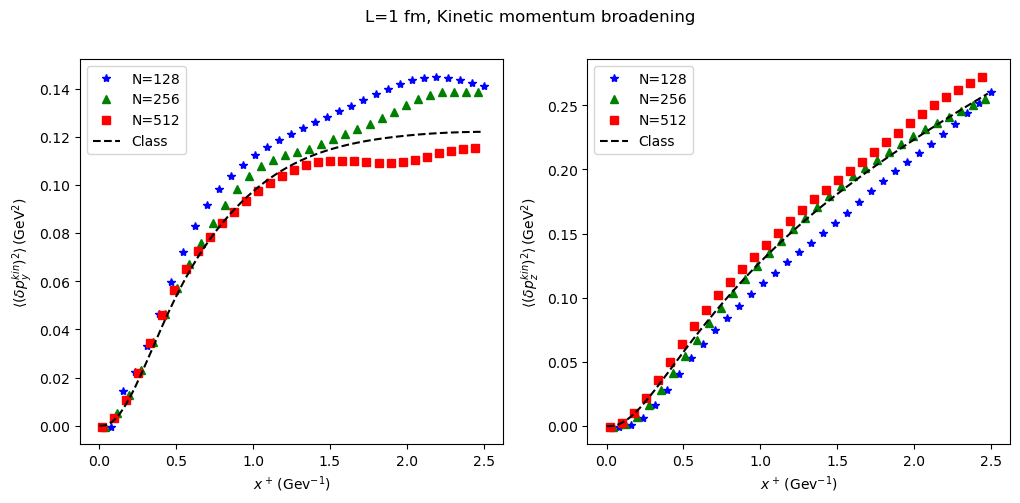

In [18]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus_128+1/(128*0.2)*2, delta_pkin_y2_128, '*', label='N=128', color='blue')
axes[0].plot(xplus_256+1/(256*0.2)*2, delta_pkin_y2_256, '^', label='N=256', color='green')
axes[0].plot(xplus_512+1/(512*0.2)*2, delta_pkin_y2_512, 's', label='N=512', color='red')
axes[0].plot(xp_class*2/0.2, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus_128+1/(128*0.2)*2, delta_pkin_z2_128, '*', label='N=128', color='blue')
axes[1].plot(xplus_256+1/(256*0.2)*2, delta_pkin_z2_256, '^', label='N=256', color='green')
axes[1].plot(xplus_512+1/(512*0.2)*2, delta_pkin_z2_512, 's', label='N=512', color='red')
axes[1].plot(xp_class*2/0.2, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=1 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=1_plots/Kinetic_momentum_broadening.png', bbox_inches='tight')

## 2. Repeat with $L=5\, \mathrm{fm}$

Let us now see if we can still get decent results in the limit where $m_g$ acts as the IR regulator and not $1/L$

### Canonic momentum broadening

In [19]:
# We create a list with the files to read

Nevs = 50

p2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [20]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_256 = []; pp0_df_list_256 = []
p2_df_list_512 = []; pp0_df_list_512 = []
p2_df_list_1024 = []; pp0_df_list_1024 = []

for i in range(Nevs):
    p2_df_256 = [pd.read_table(p2_file_list_256[i], header = None)]
    pp0_df_256 = [pd.read_table(pp0_file_list_256[i], header = None)]
    
    p2_df_512 = [pd.read_table(p2_file_list_512[i], header = None)]
    pp0_df_512 = [pd.read_table(pp0_file_list_512[i], header = None)]
    
    p2_df_1024 = [pd.read_table(p2_file_list_1024[i], header = None)]
    pp0_df_1024 = [pd.read_table(pp0_file_list_1024[i], header = None)]
    
    p2_df_list_256.append(p2_df_256); pp0_df_list_256.append(pp0_df_256)
    p2_df_list_512.append(p2_df_512); pp0_df_list_512.append(pp0_df_512)
    p2_df_list_1024.append(p2_df_1024); pp0_df_list_1024.append(pp0_df_1024)

p2_data_256 = np.array(p2_df_list_256); pp0_data_256 = np.array(pp0_df_list_256)
p2_data_512 = np.array(p2_df_list_512); pp0_data_512 = np.array(pp0_df_list_512)
p2_data_1024 = np.array(p2_df_list_1024); pp0_data_1024 = np.array(pp0_df_list_1024)

In [21]:
# We average over color and events
p2_av_256 = np.average(p2_data_256, axis=(0, 1)); pp0_av_256 = np.average(pp0_data_256, axis=(0, 1))
p2_av_512 = np.average(p2_data_512, axis=(0, 1)); pp0_av_512 = np.average(pp0_data_512, axis=(0, 1))
p2_av_1024 = np.average(p2_data_1024, axis=(0, 1)); pp0_av_1024 = np.average(pp0_data_1024, axis=(0, 1))

In [22]:
# Take the different components of canonic momentum
xplus_256 = p2_av_256[:, 0]; xplus_512 = p2_av_512[:, 0]; xplus_1024 = p2_av_1024[:, 0]

p2_z_256 = p2_av_256[:, 1]; p2_z_512 = p2_av_512[:, 1]
p2_y_256 = p2_av_256[:, 2]; p2_y_512 = p2_av_512[:, 2]

pp0_z_256 = pp0_av_256[:, 1]; pp0_z_512 = pp0_av_512[:, 1]
pp0_y_256 = pp0_av_256[:, 2]; pp0_y_512 = pp0_av_512[:, 2]

p2_z_1024 = p2_av_1024[:, 1]; p2_y_1024 = p2_av_1024[:, 2]
pp0_z_1024 = pp0_av_1024[:, 1]; pp0_y_1024 = pp0_av_1024[:, 2]

In [23]:
# We compute momentum broadening

delta_p2_y_256 = p2_y_256 + p2_y_256[0] - pp0_y_256 
delta_p2_z_256 = p2_z_256 + p2_z_256[0] - pp0_z_256

delta_p2_y_512 = p2_y_512 + p2_y_512[0] - pp0_y_512
delta_p2_z_512 = p2_z_512 + p2_z_512[0] - pp0_z_512

delta_p2_y_1024 = p2_y_1024 + p2_y_1024[0] - pp0_y_1024
delta_p2_z_1024 = p2_z_1024 + p2_z_1024[0] - pp0_z_1024

### Field contribution

In [24]:
# We create a list with the files to read

Nevs = 50

A2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [25]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_256 = []; AA0_df_list_256 = []
A2_df_list_512 = []; AA0_df_list_512 = []
A2_df_list_1024 = []; AA0_df_list_1024 = []

for i in range(Nevs):
    
    A2_df_256 = [pd.read_table(A2_file_list_256[i], header = None)]
    AA0_df_256 = [pd.read_table(AA0_file_list_256[i], header = None)]
    
    A2_df_512 = [pd.read_table(A2_file_list_512[i], header = None)]
    AA0_df_512 = [pd.read_table(AA0_file_list_512[i], header = None)]
    
    A2_df_1024 = [pd.read_table(A2_file_list_1024[i], header = None)]
    AA0_df_1024 = [pd.read_table(AA0_file_list_1024[i], header = None)]

    A2_df_list_256.append(A2_df_256); AA0_df_list_256.append(AA0_df_256)
    A2_df_list_512.append(A2_df_512); AA0_df_list_512.append(AA0_df_512)
    A2_df_list_1024.append(A2_df_1024); AA0_df_list_1024.append(AA0_df_1024)

A2_data_256 = np.array(A2_df_list_256); AA0_data_256 = np.array(AA0_df_list_256)
A2_data_512 = np.array(A2_df_list_512); AA0_data_512 = np.array(AA0_df_list_512)
A2_data_1024 = np.array(A2_df_list_1024); AA0_data_1024 = np.array(AA0_df_list_1024)

In [26]:
# We average over color and events
A2_av_256 = np.average(A2_data_256, axis=(0, 1)); AA0_av_256 = np.average(AA0_data_256, axis=(0, 1))
A2_av_512 = np.average(A2_data_512, axis=(0, 1)); AA0_av_512 = np.average(AA0_data_512, axis=(0, 1))
A2_av_1024 = np.average(A2_data_1024, axis=(0, 1)); AA0_av_1024 = np.average(AA0_data_1024, axis=(0, 1))

In [27]:
# Take the different components of canonic momentum
xplus_256 = A2_av_256[:, 0]; xplus_512 = A2_av_512[:, 0]; xplus_1024 = A2_av_1024[:, 0]

A2_z_256 = A2_av_256[:, 2]; A2_z_512 = A2_av_512[:, 2]; A2_z_1024 = A2_av_1024[:, 2]
A2_y_256 = A2_av_256[:, 6]; A2_y_512 = A2_av_512[:, 6]; A2_y_1024 = A2_av_1024[:, 6]

AA0_z_256 = AA0_av_256[:, 1]; AA0_z_512 = AA0_av_512[:, 1]; AA0_z_1024 = AA0_av_1024[:, 1]
AA0_y_256 = AA0_av_256[:, 2]; AA0_y_512 = AA0_av_512[:, 2]; AA0_y_1024 = AA0_av_1024[:, 2]

In [28]:
# We compute momentum broadening

delta_A2_y_256 = A2_y_256 + A2_y_256[0] -  AA0_y_256
delta_A2_z_256 = A2_z_256 + A2_z_256[0] - AA0_z_256

delta_A2_y_512 = A2_y_512 + A2_y_512[0] -  AA0_y_512
delta_A2_z_512 = A2_z_512 + A2_z_512[0] - AA0_z_512

delta_A2_y_1024 = A2_y_1024 + A2_y_1024[0] -  AA0_y_1024
delta_A2_z_1024 = A2_z_1024 + A2_z_1024[0] - AA0_z_1024

### Cross term

In [29]:
# We create a list with the files to read

Nevs = 50

pA_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [30]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_256 = []; pA0_df_list_256 = []; p0A_df_list_256 = []
pA_df_list_512 = []; pA0_df_list_512 = []; p0A_df_list_512 = []
pA_df_list_1024 = []; pA0_df_list_1024 = []; p0A_df_list_1024 = []

for i in range(Nevs):
    
    pA_df_256 = [pd.read_table(pA_file_list_256[i], header = None)]
    pA0_df_256 = [pd.read_table(pA0_file_list_256[i], header = None)]
    p0A_df_256 = [pd.read_table(p0A_file_list_256[i], header = None)]
    
    pA_df_512 = [pd.read_table(pA_file_list_512[i], header = None)]
    pA0_df_512 = [pd.read_table(pA0_file_list_512[i], header = None)]
    p0A_df_512 = [pd.read_table(p0A_file_list_512[i], header = None)]
    
    pA_df_1024 = [pd.read_table(pA_file_list_1024[i], header = None)]
    pA0_df_1024 = [pd.read_table(pA0_file_list_1024[i], header = None)]
    p0A_df_1024 = [pd.read_table(p0A_file_list_1024[i], header = None)]

    pA_df_list_256.append(pA_df_256); pA0_df_list_256.append(pA0_df_256); p0A_df_list_256.append(p0A_df_256)
    pA_df_list_512.append(pA_df_512); pA0_df_list_512.append(pA0_df_512); p0A_df_list_512.append(p0A_df_512)
    pA_df_list_1024.append(pA_df_1024); pA0_df_list_1024.append(pA0_df_1024); p0A_df_list_1024.append(p0A_df_1024)

pA_data_256 = np.array(pA_df_list_256); pA0_data_256 = np.array(pA0_df_list_256); p0A_data_256 = np.array(p0A_df_list_256)
pA_data_512 = np.array(pA_df_list_512); pA0_data_512 = np.array(pA0_df_list_512); p0A_data_512 = np.array(p0A_df_list_512)
pA_data_1024 = np.array(pA_df_list_1024); pA0_data_1024 = np.array(pA0_df_list_1024); p0A_data_1024 = np.array(p0A_df_list_1024)

In [31]:
# We average over color and events
pA_av_256 = np.average(pA_data_256, axis=(0, 1)); pA0_av_256 = np.average(pA0_data_256, axis=(0, 1)); p0A_av_256 = np.average(p0A_data_256, axis=(0, 1))
pA_av_512 = np.average(pA_data_512, axis=(0, 1)); pA0_av_512 = np.average(pA0_data_512, axis=(0, 1)); p0A_av_512 = np.average(p0A_data_512, axis=(0, 1))
pA_av_1024 = np.average(pA_data_1024, axis=(0, 1)); pA0_av_1024 = np.average(pA0_data_1024, axis=(0, 1)); p0A_av_1024 = np.average(p0A_data_1024, axis=(0, 1))

In [32]:
# Take the different components of canonic momentum
xplus_256 = pA_av_256[:, 0]; xplus_512 = pA_av_512[:, 0]; xplus_1024 = pA_av_1024[:, 0]

pA_z_256 = pA_av_256[:, 3]; pA_z_512 = pA_av_512[:, 3]; pA_z_1024 = pA_av_1024[:, 3]
pA_y_256 = pA_av_256[:, 7]; pA_y_512 = pA_av_512[:, 7]; pA_y_1024 = pA_av_1024[:, 7]

pA0_z_256 = pA0_av_256[:, 1]; pA0_z_512 = pA0_av_512[:, 1]; pA0_z_1024 = pA0_av_1024[:, 1]
pA0_y_256 = pA0_av_256[:, 2]; pA0_y_512 = pA0_av_512[:, 2]; pA0_y_1024 = pA0_av_1024[:, 2]

p0A_z_256 = p0A_av_256[:, 1]; p0A_z_512 = p0A_av_512[:, 1]; p0A_z_1024 = p0A_av_1024[:, 1]
p0A_y_256 = p0A_av_256[:, 2]; p0A_y_512 = p0A_av_512[:, 2]; p0A_y_1024 = p0A_av_1024[:, 2]

In [33]:
# We compute momentum broadening

delta_pA_y_256 = pA_y_256 + pA_y_256[0] -  pA0_y_256 - p0A_y_256
delta_pA_z_256 = pA_z_256 + pA_z_256[0] -  pA0_z_256 - p0A_z_256

delta_pA_y_512 = pA_y_512 + pA_y_512[0] -  pA0_y_512 - p0A_y_512
delta_pA_z_512 = pA_z_512 + pA_z_512[0] -  pA0_z_512 - p0A_z_512

delta_pA_y_1024 = pA_y_1024 + pA_y_1024[0] -  pA0_y_1024 - p0A_y_1024
delta_pA_z_1024 = pA_z_1024 + pA_z_1024[0] -  pA0_z_1024 - p0A_z_1024

### Kinetic momentum

In [34]:
# We compute the quantum result

delta_pkin_y2_256 = delta_p2_y_256 + delta_A2_y_256 + delta_pA_y_256
delta_pkin_z2_256 = delta_p2_z_256 + delta_A2_z_256 + delta_pA_z_256

delta_pkin_y2_512 = delta_p2_y_512 + delta_A2_y_512 + delta_pA_y_512
delta_pkin_z2_512 = delta_p2_z_512 + delta_A2_z_512 + delta_pA_z_512

delta_pkin_y2_1024 = delta_p2_y_1024 + delta_A2_y_1024 + delta_pA_y_1024
delta_pkin_z2_1024 = delta_p2_z_1024 + delta_A2_z_1024 + delta_pA_z_1024

In [35]:
# We load the classical result

xp_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[2]

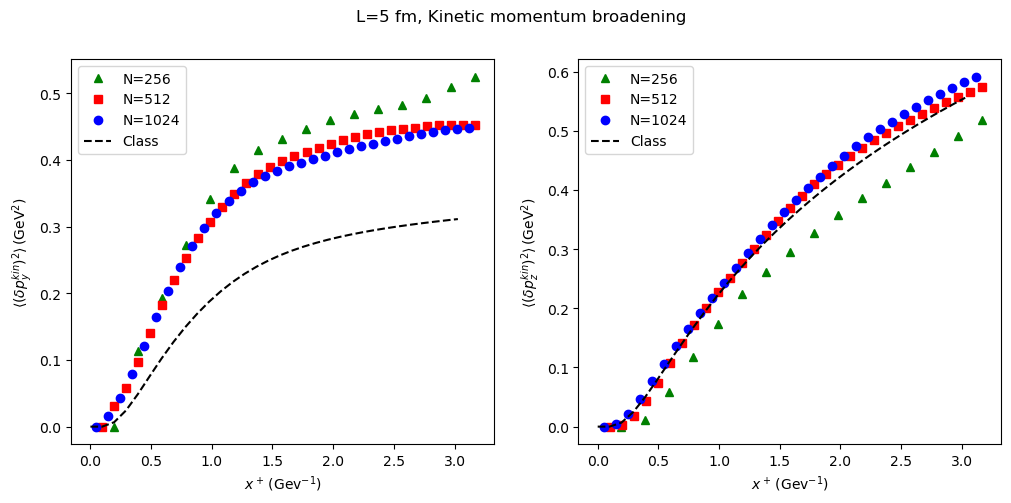

In [36]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus_256+5/(256*0.2)*2, delta_pkin_y2_256, '^', label='N=256', color='green')
axes[0].plot(xplus_512+5/(512*0.2)*2, delta_pkin_y2_512, 's', label='N=512', color='red')
axes[0].plot(xplus_1024+5/(1024*0.2)*2, delta_pkin_y2_1024, 'o', label='N=1024', color='blue')
axes[0].plot(xp_class*2/0.2, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus_256+5/(256*0.2)*2, delta_pkin_z2_256, '^', label='N=256', color='green')
axes[1].plot(xplus_512+5/(512*0.2)*2, delta_pkin_z2_512, 's', label='N=512', color='red')
axes[1].plot(xplus_1024+5/(1024*0.2)*2, delta_pkin_z2_1024, 'o', label='N=1024', color='blue')
axes[1].plot(xp_class*2/0.2, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

# fig.savefig('L=5_plots/Kinetic_momentum_broadening.png', bbox_inches='tight')

## 3. Compare to mid-rapidity

We want to check if the discrepancies in the $y$ direction come from the change of coordinates

In [1]:
# We create a list with the files to read

Nevs = 50

p2_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list = []; pp0_df_list = []
p2_df_list_mr = []; pp0_df_list_mr = []

for i in range(Nevs):
    
    p2_df = [pd.read_table(p2_file_list[i], header = None)]
    pp0_df = [pd.read_table(pp0_file_list[i], header = None)]
    
    p2_df_mr = [pd.read_table(p2_file_list_mr[i], header = None)]
    pp0_df_mr = [pd.read_table(pp0_file_list_mr[i], header = None)]
    
    p2_df_list.append(p2_df); pp0_df_list.append(pp0_df)
    p2_df_list_mr.append(p2_df_mr); pp0_df_list_mr.append(pp0_df_mr)
    
p2_data = np.array(p2_df_list); pp0_data = np.array(pp0_df_list)
p2_data_mr = np.array(p2_df_list_mr); pp0_data_mr = np.array(pp0_df_list_mr)

In [3]:
# We average over color and events
p2_av = np.average(p2_data, axis=(0, 1)); pp0_av = np.average(pp0_data, axis=(0, 1))
p2_av_mr = np.average(p2_data_mr, axis=(0, 1)); pp0_av_mr = np.average(pp0_data_mr, axis=(0, 1))

In [4]:
# Take the different components of canonic momentum
xplus = p2_av[:, 0]

p2_z = p2_av[:, 1]; p2_y = p2_av[:, 2]
p2_z_mr = p2_av_mr[:, 1]; p2_y_mr = p2_av_mr[:, 2]

pp0_z = pp0_av[:, 1]; pp0_y = pp0_av[:, 2]
pp0_z_mr = pp0_av_mr[:, 1]; pp0_y_mr = pp0_av_mr[:, 2]


In [5]:
# We compute momentum broadening

delta_p2_y = p2_y + p2_y[0] - pp0_y
delta_p2_z = p2_z + p2_z[0] - pp0_z

delta_p2_y_mr = p2_y_mr + p2_y_mr[0] - pp0_y_mr
delta_p2_z_mr = p2_z_mr + p2_z_mr[0] - pp0_z_mr

In [6]:
print(delta_p2_y_mr)
print(delta_p2_z_mr)

[0.        0.0205974 0.0810152 0.175827  0.2962092 0.4318792 0.5731322
 0.7124384 0.8452918 0.9700606 1.0869784 1.1968786 1.3002788 1.397112
 1.486887  1.5689724 1.642886  1.7087152 1.767431  1.8207284 1.8703866
 1.91757   1.9625644 2.0050984 2.0449946 2.0826324 2.118956  2.155022
 2.1913592 2.2275946 2.2626732 2.295626        nan]
[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. nan]


### Field contribution

In [7]:
# We create a list with the files to read

Nevs = 50

A2_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [8]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list = []; AA0_df_list = []
A2_df_list_mr = []; AA0_df_list_mr = []

for i in range(Nevs):
    
    A2_df = [pd.read_table(A2_file_list[i], header = None)]
    AA0_df = [pd.read_table(AA0_file_list[i], header = None)]
    
    A2_df_mr = [pd.read_table(A2_file_list_mr[i], header = None)]
    AA0_df_mr = [pd.read_table(AA0_file_list_mr[i], header = None)]
    
    A2_df_list.append(A2_df); AA0_df_list.append(AA0_df)
    A2_df_list_mr.append(A2_df_mr); AA0_df_list_mr.append(AA0_df_mr)

A2_data = np.array(A2_df_list); AA0_data = np.array(AA0_df_list)
A2_data_mr = np.array(A2_df_list_mr); AA0_data_mr = np.array(AA0_df_list_mr)

In [9]:
# We average over color and events
A2_av = np.average(A2_data, axis=(0, 1)); AA0_av = np.average(AA0_data, axis=(0, 1))
A2_av_mr = np.average(A2_data_mr, axis=(0, 1)); AA0_av_mr = np.average(AA0_data_mr, axis=(0, 1))

In [10]:
# Take the different components of canonic momentum
xplus = A2_av[:, 0]

A2_z = A2_av[:, 2]; A2_z_mr = A2_av_mr[:, 2]
A2_y = A2_av[:, 6]; A2_y_mr = A2_av_mr[:, 6]

AA0_z = AA0_av[:, 1]; AA0_z_mr = AA0_av_mr[:, 1]
AA0_y = AA0_av[:, 2]; AA0_y_mr = AA0_av_mr[:, 2]

In [11]:
# We compute momentum broadening

delta_A2_y = A2_y + A2_y[0] -  AA0_y
delta_A2_z = A2_z + A2_z[0] - AA0_z

delta_A2_y_mr = A2_y_mr + A2_y_mr[0] -  AA0_y_mr
delta_A2_z_mr = A2_z_mr + A2_z_mr[0] - AA0_z_mr

In [12]:
print(delta_A2_y)
print(delta_A2_y_mr)

[2.00000000e-07 1.34524400e-02 5.60392400e-02 1.43097080e-01
 2.66217180e-01 4.14426660e-01 5.76426040e-01 7.42147880e-01
 9.04166700e-01 1.05759022e+00 1.19842189e+00 1.32332795e+00
 1.43129806e+00 1.52475958e+00 1.60798524e+00 1.68429962e+00
 1.75516375e+00 1.82112904e+00 1.88274601e+00 1.94048952e+00
 1.99441470e+00 2.04414863e+00 2.08895275e+00 2.12773836e+00
 2.15880768e+00 2.18015654e+00 2.19091062e+00 2.19255429e+00
 2.18880161e+00 2.18432092e+00 2.18342781e+00 2.18909459e+00
 1.32441288e+00]
[-4.44089210e-16  1.94367000e-02  7.93094800e-02  1.90190140e-01
  3.37387340e-01  5.05739420e-01  6.82515880e-01  8.57794640e-01
  1.02462520e+00  1.17875972e+00  1.31805556e+00  1.44257132e+00
  1.55387125e+00  1.65348004e+00  1.74242104e+00  1.82143129e+00
  1.89077787e+00  1.95015939e+00  1.99962383e+00  2.04090622e+00
  2.07734031e+00  2.11195674e+00  2.14597541e+00  2.17912366e+00
  2.21084492e+00  2.24081958e+00  2.26881966e+00  2.29497304e+00
  2.32005657e+00  2.34520761e+00  2.3718

### Cross term

In [13]:
# We create a list with the files to read

Nevs = 50

pA_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [14]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list = []; pA0_df_list = []; p0A_df_list = []
pA_df_list_mr = []; pA0_df_list_mr = []; p0A_df_list_mr = []

for i in range(Nevs):
    
    pA_df = [pd.read_table(pA_file_list_512[i], header = None)]
    pA0_df = [pd.read_table(pA0_file_list_512[i], header = None)]
    p0A_df = [pd.read_table(p0A_file_list_512[i], header = None)]
    
    pA_df_mr = [pd.read_table(pA_file_list_mr[i], header = None)]
    pA0_df_mr = [pd.read_table(pA0_file_list_mr[i], header = None)]
    p0A_df_mr = [pd.read_table(p0A_file_list_mr[i], header = None)]
    
    pA_df_list.append(pA_df); pA0_df_list.append(pA0_df); p0A_df_list.append(p0A_df)
    pA_df_list_mr.append(pA_df_mr); pA0_df_list_mr.append(pA0_df_mr); p0A_df_list_mr.append(p0A_df_mr)

pA_data = np.array(pA_df_list); pA0_data = np.array(pA0_df_list); p0A_data = np.array(p0A_df_list)
pA_data_mr = np.array(pA_df_list_mr); pA0_data_mr = np.array(pA0_df_list_mr); p0A_data_mr = np.array(p0A_df_list_mr)

In [15]:
# We average over color and events
pA_av = np.average(pA_data, axis=(0, 1)); pA0_av = np.average(pA0_data, axis=(0, 1)); p0A_av = np.average(p0A_data, axis=(0, 1))
pA_av_mr = np.average(pA_data_mr, axis=(0, 1)); pA0_av_mr = np.average(pA0_data_mr, axis=(0, 1)); p0A_av_mr = np.average(p0A_data_mr, axis=(0, 1))

In [16]:
# Take the different components of canonic momentum
xplus = pA_av[:, 0]

pA_z = pA_av[:, 3]; pA_y = pA_av[:, 7]
pA_z_mr = pA_av_mr[:, 3]; pA_y_mr = pA_av_mr[:, 7]

pA0_z = pA0_av[:, 1]; pA0_y = pA0_av[:, 2]
pA0_z_mr = pA0_av_mr[:, 1]; pA0_y_mr = pA0_av_mr[:, 2]

p0A_z = p0A_av[:, 1]; p0A_y = p0A_av[:, 2]
p0A_z_mr = p0A_av_mr[:, 1]; p0A_y_mr = p0A_av_mr[:, 2]

In [17]:
# We compute momentum broadening

delta_pA_y = pA_y + pA_y[0] -  pA0_y - p0A_y
delta_pA_z = pA_z + pA_z[0] -  pA0_z - p0A_z

delta_pA_y_mr = pA_y_mr + pA_y_mr[0] -  pA0_y_mr - p0A_y_mr
delta_pA_z_mr = pA_z_mr + pA_z_mr[0] -  pA0_z_mr - p0A_z_mr

### Compute kinetic momentum

In [18]:
# We compute the quantum result

delta_pkin_y2 = delta_p2_y + delta_A2_y + delta_pA_y
delta_pkin_z2 = delta_p2_z + delta_A2_z + delta_pA_z

delta_pkin_y2_mr = delta_p2_y_mr + delta_A2_y_mr + delta_pA_y_mr
delta_pkin_z2_mr = delta_p2_z_mr + delta_A2_z_mr + delta_pA_z_mr

In [19]:
# We load the classical result

xp_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[2]

NameError: name 'delta_pkin_y2_mr' is not defined

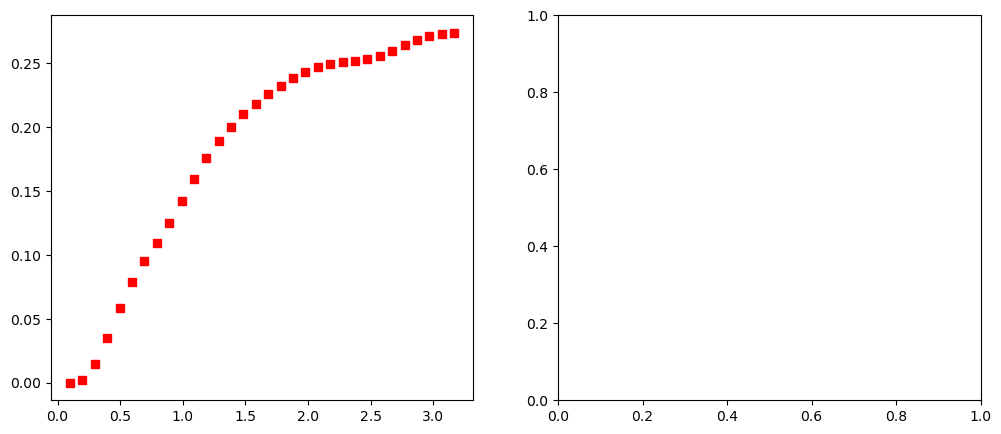

In [25]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus+5/(512*0.197326)*2, delta_pkin_y2, 's', label='1st order', color='red')
axes[0].plot(xplus+5/(512*0.197326)*2, delta_pkin_y2_mr, 'o', label='Mid Rapidity', color='blue')
axes[0].plot(xp_class*2/0.197326, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus+5/(512*0.197326)*2, delta_pkin_z2, 's', label='1st order', color='red')
axes[1].plot(xplus+5/(512*0.197326)*2, delta_pkin_z2_mr, 'o', label='Mid Rapidity', color='blue')
axes[1].plot(xp_class*2/0.197326, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=5_plots/Kinetic_momentum_mid_rapidity.png', bbox_inches='tight')

## 4. Coulomb gauge

Let us see if we can reproduce the classical results using the Coulomb gauge fields

### Canonic momentum broadening

In [1]:
# We create a list with the files to read

Nevs = 100

p2_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]


p2_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]


In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_w5 = []; pp0_df_list_w5 = []
p2_df_list_w10 = []; pp0_df_list_w10 = []
p2_df_list_w20 = []; pp0_df_list_w20 = []
p2_df_list_w40 = []; pp0_df_list_w40 = []
p2_df_list_w80 = []; pp0_df_list_w80 = []
p2_df_list_w160 = []; pp0_df_list_w160 = []
for i in range(Nevs):
    
    p2_df_w5 = [pd.read_table(p2_file_list_w5[i], header = None)]
    pp0_df_w5 = [pd.read_table(pp0_file_list_w5[i], header = None)]
    
    p2_df_w10 = [pd.read_table(p2_file_list_w10[i], header = None)]
    pp0_df_w10 = [pd.read_table(pp0_file_list_w10[i], header = None)]
    
    p2_df_w20 = [pd.read_table(p2_file_list_w20[i], header = None)]
    pp0_df_w20 = [pd.read_table(pp0_file_list_w20[i], header = None)]
    
    p2_df_w40 = [pd.read_table(p2_file_list_w40[i], header = None)]
    pp0_df_w40 = [pd.read_table(pp0_file_list_w40[i], header = None)]
    
    p2_df_w80 = [pd.read_table(p2_file_list_w80[i], header = None)]
    pp0_df_w80 = [pd.read_table(pp0_file_list_w80[i], header = None)]
    
    p2_df_w160 = [pd.read_table(p2_file_list_w160[i], header = None)]
    pp0_df_w160 = [pd.read_table(pp0_file_list_w160[i], header = None)]
    
    
    p2_df_list_w5.append(p2_df_w5); pp0_df_list_w5.append(pp0_df_w5)
    p2_df_list_w10.append(p2_df_w10); pp0_df_list_w10.append(pp0_df_w10)
    p2_df_list_w20.append(p2_df_w20); pp0_df_list_w20.append(pp0_df_w20)
    p2_df_list_w40.append(p2_df_w40); pp0_df_list_w40.append(pp0_df_w40)
    p2_df_list_w80.append(p2_df_w80); pp0_df_list_w80.append(pp0_df_w80)
    p2_df_list_w160.append(p2_df_w160); pp0_df_list_w160.append(pp0_df_w160)
    
p2_data_w5 = np.array(p2_df_list_w5); pp0_data_w5 = np.array(pp0_df_list_w5)
p2_data_w10 = np.array(p2_df_list_w10); pp0_data_w10 = np.array(pp0_df_list_w10)
p2_data_w20 = np.array(p2_df_list_w20); pp0_data_w20 = np.array(pp0_df_list_w20)
p2_data_w40 = np.array(p2_df_list_w40); pp0_data_w40 = np.array(pp0_df_list_w40)
p2_data_w80 = np.array(p2_df_list_w80); pp0_data_w80 = np.array(pp0_df_list_w80)
p2_data_w160 = np.array(p2_df_list_w160); pp0_data_w160 = np.array(pp0_df_list_w160)

In [3]:
# We average over events
p2_av_5 = np.average(p2_data_w5, axis=(0, 1)); pp0_av_w5 = np.average(pp0_data_w5, axis=(0, 1))
p2_av_10 = np.average(p2_data_w10, axis=(0, 1)); pp0_av_w10 = np.average(pp0_data_w10, axis=(0, 1))
p2_av_20 = np.average(p2_data_w20, axis=(0, 1)); pp0_av_w20 = np.average(pp0_data_w20, axis=(0, 1))
p2_av_40 = np.average(p2_data_w40, axis=(0, 1)); pp0_av_w40 = np.average(pp0_data_w40, axis=(0, 1))
p2_av_80 = np.average(p2_data_w80, axis=(0, 1)); pp0_av_w80 = np.average(pp0_data_w80, axis=(0, 1))
p2_av_160 = np.average(p2_data_w160, axis=(0, 1)); pp0_av_w160 = np.average(pp0_data_w160, axis=(0, 1))

In [4]:
# Take the different components of canonic momentum
xplus = p2_av_10[:, 0]

p2_z_w5 = p2_av_5[:, 1]; p2_y_w5 = p2_av_5[:, 2]
pp0_z_w5 = pp0_av_w5[:, 1]; pp0_y_w5 = pp0_av_w5[:, 2]

p2_z_w10 = p2_av_10[:, 1]; p2_y_w10 = p2_av_10[:, 2]
pp0_z_w10 = pp0_av_w10[:, 1]; pp0_y_w10 = pp0_av_w10[:, 2]

p2_z_w20 = p2_av_20[:, 1]; p2_y_w20 = p2_av_20[:, 2]
pp0_z_w20 = pp0_av_w20[:, 1]; pp0_y_w20 = pp0_av_w20[:, 2]

p2_z_w40 = p2_av_40[:, 1]; p2_y_w40 = p2_av_40[:, 2]
pp0_z_w40 = pp0_av_w40[:, 1]; pp0_y_w40 = pp0_av_w40[:, 2]

p2_z_w80 = p2_av_80[:, 1]; p2_y_w80 = p2_av_80[:, 2]
pp0_z_w80 = pp0_av_w80[:, 1]; pp0_y_w80 = pp0_av_w80[:, 2]

p2_z_w160 = p2_av_160[:, 1]; p2_y_w160 = p2_av_160[:, 2]
pp0_z_w160 = pp0_av_w160[:, 1]; pp0_y_w160 = pp0_av_w160[:, 2]

In [5]:
# We compute momentum broadening

delta_p2_y_w5 = p2_y_w5 + p2_y_w5[0] - pp0_y_w5
delta_p2_z_w5 = p2_z_w5 + p2_z_w5[0] - pp0_z_w5

delta_p2_y_w10 = p2_y_w10 + p2_y_w10[0] - pp0_y_w10
delta_p2_z_w10 = p2_z_w10 + p2_z_w10[0] - pp0_z_w10

delta_p2_y_w20 = p2_y_w20 + p2_y_w20[0] - pp0_y_w20
delta_p2_z_w20 = p2_z_w20 + p2_z_w20[0] - pp0_z_w20

delta_p2_y_w40 = p2_y_w40 + p2_y_w40[0] - pp0_y_w40
delta_p2_z_w40 = p2_z_w40 + p2_z_w40[0] - pp0_z_w40

delta_p2_y_w80 = p2_y_w80 + p2_y_w80[0] - pp0_y_w80
delta_p2_z_w80 = p2_z_w80 + p2_z_w80[0] - pp0_z_w80

delta_p2_y_w160 = p2_y_w160 + p2_y_w160[0] - pp0_y_w160
delta_p2_z_w160 = p2_z_w160 + p2_z_w160[0] - pp0_z_w160

### Field contribution

In [6]:
# We create a list with the files to read

Nevs = 100

A2_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]


In [7]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_w5 = []; AA0_df_list_w5 = []
A2_df_list_w10 = []; AA0_df_list_w10 = []
A2_df_list_w20 = []; AA0_df_list_w20 = []
A2_df_list_w40 = []; AA0_df_list_w40 = []
A2_df_list_w80 = []; AA0_df_list_w80 = []
A2_df_list_w160 = []; AA0_df_list_w160 = []

for i in range(Nevs):
    
    A2_df_w5 = [pd.read_table(A2_file_list_w5[i], header = None)]
    AA0_df_w5 = [pd.read_table(AA0_file_list_w5[i], header = None)]
    
    A2_df_w10 = [pd.read_table(A2_file_list_w10[i], header = None)]
    AA0_df_w10 = [pd.read_table(AA0_file_list_w10[i], header = None)]
    
    A2_df_w20 = [pd.read_table(A2_file_list_w20[i], header = None)]
    AA0_df_w20 = [pd.read_table(AA0_file_list_w20[i], header = None)]
    
    A2_df_w40 = [pd.read_table(A2_file_list_w40[i], header = None)]
    AA0_df_w40 = [pd.read_table(AA0_file_list_w40[i], header = None)]
    
    A2_df_w80 = [pd.read_table(A2_file_list_w80[i], header = None)]
    AA0_df_w80 = [pd.read_table(AA0_file_list_w80[i], header = None)]
    
    A2_df_w160 = [pd.read_table(A2_file_list_w160[i], header = None)]
    AA0_df_w160 = [pd.read_table(AA0_file_list_w160[i], header = None)]
    
    A2_df_list_w5.append(A2_df_w5); AA0_df_list_w5.append(AA0_df_w5)
    A2_df_list_w10.append(A2_df_w10); AA0_df_list_w10.append(AA0_df_w10)
    A2_df_list_w20.append(A2_df_w20); AA0_df_list_w20.append(AA0_df_w20)
    A2_df_list_w40.append(A2_df_w40); AA0_df_list_w40.append(AA0_df_w40)
    A2_df_list_w80.append(A2_df_w80); AA0_df_list_w80.append(AA0_df_w80)
    A2_df_list_w160.append(A2_df_w160); AA0_df_list_w160.append(AA0_df_w160)

A2_data_w5 = np.array(A2_df_list_w5); AA0_data_w5 = np.array(AA0_df_list_w5)
A2_data_w10 = np.array(A2_df_list_w10); AA0_data_w10 = np.array(AA0_df_list_w10)
A2_data_w20 = np.array(A2_df_list_w20); AA0_data_w20 = np.array(AA0_df_list_w20)
A2_data_w40 = np.array(A2_df_list_w40); AA0_data_w40 = np.array(AA0_df_list_w40)
A2_data_w80 = np.array(A2_df_list_w80); AA0_data_w80 = np.array(AA0_df_list_w80)
A2_data_w160 = np.array(A2_df_list_w160); AA0_data_w160 = np.array(AA0_df_list_w160)

In [8]:
# We average over events
A2_av_w5 = np.average(A2_data_w5, axis=(0, 1)); AA0_av_w5 = np.average(AA0_data_w5, axis=(0, 1))
A2_av_w10 = np.average(A2_data_w10, axis=(0, 1)); AA0_av_w10 = np.average(AA0_data_w10, axis=(0, 1))
A2_av_w20 = np.average(A2_data_w20, axis=(0, 1)); AA0_av_w20 = np.average(AA0_data_w20, axis=(0, 1))
A2_av_w40 = np.average(A2_data_w40, axis=(0, 1)); AA0_av_w40 = np.average(AA0_data_w40, axis=(0, 1))
A2_av_w80 = np.average(A2_data_w80, axis=(0, 1)); AA0_av_w80 = np.average(AA0_data_w80, axis=(0, 1))
A2_av_w160 = np.average(A2_data_w160, axis=(0, 1)); AA0_av_w160 = np.average(AA0_data_w160, axis=(0, 1))

In [9]:
# Take the different components of canonic momentum
xplus = A2_av_w10[:, 0]

A2_z_w5 = A2_av_w5[:, 2]; A2_y_w5 = A2_av_w5[:, 6]
AA0_z_w5 = AA0_av_w5[:, 1]; AA0_y_w5 = AA0_av_w5[:, 2]

A2_z_w10 = A2_av_w10[:, 2]; A2_y_w10 = A2_av_w10[:, 6]
AA0_z_w10 = AA0_av_w10[:, 1]; AA0_y_w10 = AA0_av_w10[:, 2]

A2_z_w20 = A2_av_w20[:, 2]; A2_y_w20 = A2_av_w20[:, 6]
AA0_z_w20 = AA0_av_w20[:, 1]; AA0_y_w20 = AA0_av_w20[:, 2]

A2_z_w40 = A2_av_w40[:, 2]; A2_y_w40 = A2_av_w40[:, 6]
AA0_z_w40 = AA0_av_w40[:, 1]; AA0_y_w40 = AA0_av_w40[:, 2]

A2_z_w80 = A2_av_w80[:, 2]; A2_y_w80 = A2_av_w80[:, 6]
AA0_z_w80 = AA0_av_w80[:, 1]; AA0_y_w80 = AA0_av_w80[:, 2]

A2_z_w160 = A2_av_w160[:, 2]; A2_y_w160 = A2_av_w160[:, 6]
AA0_z_w160 = AA0_av_w160[:, 1]; AA0_y_w160 = AA0_av_w160[:, 2]

In [10]:
# We compute momentum broadening

delta_A2_y_w5 = A2_y_w5 + A2_y_w5[0] -  AA0_y_w5
delta_A2_z_w5 = A2_z_w5 + A2_z_w5[0] - AA0_z_w5

delta_A2_y_w10 = A2_y_w10 + A2_y_w10[0] -  AA0_y_w10
delta_A2_z_w10 = A2_z_w10 + A2_z_w10[0] - AA0_z_w10

delta_A2_y_w20 = A2_y_w20 + A2_y_w20[0] -  AA0_y_w20
delta_A2_z_w20 = A2_z_w20 + A2_z_w20[0] - AA0_z_w20

delta_A2_y_w40 = A2_y_w40 + A2_y_w40[0] -  AA0_y_w40
delta_A2_z_w40 = A2_z_w40 + A2_z_w40[0] - AA0_z_w40

delta_A2_y_w80 = A2_y_w80 + A2_y_w80[0] -  AA0_y_w80
delta_A2_z_w80 = A2_z_w80 + A2_z_w80[0] - AA0_z_w80

delta_A2_y_w160 = A2_y_w160 + A2_y_w160[0] -  AA0_y_w160
delta_A2_z_w160 = A2_z_w160 + A2_z_w160[0] - AA0_z_w160

### Cross term

In [13]:
# We create a list with the files to read

Nevs = 100

pA_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [14]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_w5 = []; pA0_df_list_w5 = []; p0A_df_list_w5 = []
pA_df_list_w10 = []; pA0_df_list_w10 = []; p0A_df_list_w10 = []
pA_df_list_w20 = []; pA0_df_list_w20 = []; p0A_df_list_w20 = []
pA_df_list_w40 = []; pA0_df_list_w40 = []; p0A_df_list_w40 = []
pA_df_list_w80 = []; pA0_df_list_w80 = []; p0A_df_list_w80 = []
pA_df_list_w160 = []; pA0_df_list_w160 = []; p0A_df_list_w160 = []
for i in range(Nevs):
    
    pA_df_w5 = [pd.read_table(pA_file_list_w5[i], header = None)]
    pA0_df_w5 = [pd.read_table(pA0_file_list_w5[i], header = None)]
    p0A_df_w5 = [pd.read_table(p0A_file_list_w5[i], header = None)]
    
    pA_df_w10 = [pd.read_table(pA_file_list_w10[i], header = None)]
    pA0_df_w10 = [pd.read_table(pA0_file_list_w10[i], header = None)]
    p0A_df_w10 = [pd.read_table(p0A_file_list_w10[i], header = None)]
    
    pA_df_w20 = [pd.read_table(pA_file_list_w20[i], header = None)]
    pA0_df_w20 = [pd.read_table(pA0_file_list_w20[i], header = None)]
    p0A_df_w20 = [pd.read_table(p0A_file_list_w20[i], header = None)]
    
    pA_df_w40 = [pd.read_table(pA_file_list_w40[i], header = None)]
    pA0_df_w40 = [pd.read_table(pA0_file_list_w40[i], header = None)]
    p0A_df_w40 = [pd.read_table(p0A_file_list_w40[i], header = None)]
    
    pA_df_w80 = [pd.read_table(pA_file_list_w80[i], header = None)]
    pA0_df_w80 = [pd.read_table(pA0_file_list_w80[i], header = None)]
    p0A_df_w80 = [pd.read_table(p0A_file_list_w80[i], header = None)]
    
    pA_df_w160 = [pd.read_table(pA_file_list_w160[i], header = None)]
    pA0_df_w160 = [pd.read_table(pA0_file_list_w160[i], header = None)]
    p0A_df_w160 = [pd.read_table(p0A_file_list_w160[i], header = None)]
    
    pA_df_list_w5.append(pA_df_w5); pA0_df_list_w5.append(pA0_df_w5); p0A_df_list_w5.append(p0A_df_w5)
    pA_df_list_w10.append(pA_df_w10); pA0_df_list_w10.append(pA0_df_w10); p0A_df_list_w10.append(p0A_df_w10)
    pA_df_list_w20.append(pA_df_w20); pA0_df_list_w20.append(pA0_df_w20); p0A_df_list_w20.append(p0A_df_w20)
    pA_df_list_w40.append(pA_df_w40); pA0_df_list_w40.append(pA0_df_w40); p0A_df_list_w40.append(p0A_df_w40)
    pA_df_list_w80.append(pA_df_w80); pA0_df_list_w80.append(pA0_df_w80); p0A_df_list_w80.append(p0A_df_w80)
    pA_df_list_w160.append(pA_df_w160); pA0_df_list_w160.append(pA0_df_w160); p0A_df_list_w160.append(p0A_df_w160)

pA_data_w5 = np.array(pA_df_list_w5); pA0_data_w5 = np.array(pA0_df_list_w5); p0A_data_w5 = np.array(p0A_df_list_w5)
pA_data_w10 = np.array(pA_df_list_w10); pA0_data_w10 = np.array(pA0_df_list_w10); p0A_data_w10 = np.array(p0A_df_list_w10)
pA_data_w20 = np.array(pA_df_list_w20); pA0_data_w20 = np.array(pA0_df_list_w20); p0A_data_w20 = np.array(p0A_df_list_w20)
pA_data_w40 = np.array(pA_df_list_w40); pA0_data_w40 = np.array(pA0_df_list_w40); p0A_data_w40 = np.array(p0A_df_list_w40)
pA_data_w80 = np.array(pA_df_list_w80); pA0_data_w80 = np.array(pA0_df_list_w80); p0A_data_w80 = np.array(p0A_df_list_w80)
pA_data_w160 = np.array(pA_df_list_w160); pA0_data_w160 = np.array(pA0_df_list_w160); p0A_data_w160 = np.array(p0A_df_list_w160)

In [15]:
# We average over events
pA_av_w5 = np.average(pA_data_w5, axis=(0, 1)); pA0_av_w5 = np.average(pA0_data_w5, axis=(0, 1)); p0A_av_w5 = np.average(p0A_data_w5, axis=(0, 1))
pA_av_w10 = np.average(pA_data_w10, axis=(0, 1)); pA0_av_w10 = np.average(pA0_data_w10, axis=(0, 1)); p0A_av_w10 = np.average(p0A_data_w10, axis=(0, 1))
pA_av_w20 = np.average(pA_data_w20, axis=(0, 1)); pA0_av_w20 = np.average(pA0_data_w20, axis=(0, 1)); p0A_av_w20 = np.average(p0A_data_w20, axis=(0, 1))
pA_av_w40 = np.average(pA_data_w40, axis=(0, 1)); pA0_av_w40 = np.average(pA0_data_w40, axis=(0, 1)); p0A_av_w40 = np.average(p0A_data_w40, axis=(0, 1))
pA_av_w80 = np.average(pA_data_w80, axis=(0, 1)); pA0_av_w80 = np.average(pA0_data_w80, axis=(0, 1)); p0A_av_w80 = np.average(p0A_data_w80, axis=(0, 1))
pA_av_w160 = np.average(pA_data_w160, axis=(0, 1)); pA0_av_w160 = np.average(pA0_data_w160, axis=(0, 1)); p0A_av_w160 = np.average(p0A_data_w160, axis=(0, 1))

In [16]:
# Take the different components of canonic momentum
xplus = pA_av_w10[:, 0]

pA_z_w5 = pA_av_w5[:, 3]; pA_y_w5 = pA_av_w5[:, 7]
pA0_z_w5 = pA0_av_w5[:, 1]; pA0_y_w5 = pA0_av_w5[:, 2]
p0A_z_w5 = p0A_av_w5[:, 1]; p0A_y_w5 = p0A_av_w5[:, 2]

pA_z_w10 = pA_av_w10[:, 3]; pA_y_w10 = pA_av_w10[:, 7]
pA0_z_w10 = pA0_av_w10[:, 1]; pA0_y_w10 = pA0_av_w10[:, 2]
p0A_z_w10 = p0A_av_w10[:, 1]; p0A_y_w10 = p0A_av_w10[:, 2]

pA_z_w20 = pA_av_w20[:, 3]; pA_y_w20 = pA_av_w20[:, 7]
pA0_z_w20 = pA0_av_w20[:, 1]; pA0_y_w20 = pA0_av_w20[:, 2]
p0A_z_w20 = p0A_av_w20[:, 1]; p0A_y_w20 = p0A_av_w20[:, 2]

pA_z_w40 = pA_av_w40[:, 3]; pA_y_w40 = pA_av_w40[:, 7]
pA0_z_w40 = pA0_av_w40[:, 1]; pA0_y_w40 = pA0_av_w40[:, 2]
p0A_z_w40 = p0A_av_w40[:, 1]; p0A_y_w40 = p0A_av_w40[:, 2]

pA_z_w80 = pA_av_w80[:, 3]; pA_y_w80 = pA_av_w80[:, 7]
pA0_z_w80 = pA0_av_w80[:, 1]; pA0_y_w80 = pA0_av_w80[:, 2]
p0A_z_w80 = p0A_av_w80[:, 1]; p0A_y_w80 = p0A_av_w80[:, 2]

pA_z_w160 = pA_av_w160[:, 3]; pA_y_w160 = pA_av_w160[:, 7]
pA0_z_w160 = pA0_av_w160[:, 1]; pA0_y_w160 = pA0_av_w160[:, 2]
p0A_z_w160 = p0A_av_w160[:, 1]; p0A_y_w160 = p0A_av_w160[:, 2]

In [17]:
# We compute momentum broadening

delta_pA_y_w5 = pA_y_w5 + pA_y_w5[0] -  pA0_y_w5 - p0A_y_w5
delta_pA_z_w5 = pA_z_w5 + pA_z_w5[0] -  pA0_z_w5 - p0A_z_w5

delta_pA_y_w10 = pA_y_w10 + pA_y_w10[0] -  pA0_y_w10 - p0A_y_w10
delta_pA_z_w10 = pA_z_w10 + pA_z_w10[0] -  pA0_z_w10 - p0A_z_w10

delta_pA_y_w20 = pA_y_w20 + pA_y_w20[0] -  pA0_y_w20 - p0A_y_w20
delta_pA_z_w20 = pA_z_w20 + pA_z_w20[0] -  pA0_z_w20 - p0A_z_w20

delta_pA_y_w40 = pA_y_w40 + pA_y_w40[0] -  pA0_y_w40 - p0A_y_w40
delta_pA_z_w40 = pA_z_w40 + pA_z_w40[0] -  pA0_z_w40 - p0A_z_w40

delta_pA_y_w80 = pA_y_w80 + pA_y_w80[0] -  pA0_y_w80 - p0A_y_w80
delta_pA_z_w80 = pA_z_w80 + pA_z_w80[0] -  pA0_z_w80 - p0A_z_w80

delta_pA_y_w160 = pA_y_w160 + pA_y_w160[0] -  pA0_y_w160 - p0A_y_w160
delta_pA_z_w160 = pA_z_w160 + pA_z_w160[0] -  pA0_z_w160 - p0A_z_w160

### Compute kinetic momentum broadening

In [18]:
# We compute the quantum result

delta_pkin_y2_w5 = delta_p2_y_w5 + delta_A2_y_w5 + delta_pA_y_w5
delta_pkin_z2_w5 = delta_p2_z_w5 + delta_A2_z_w5 + delta_pA_z_w5

delta_pkin_y2_w10 = delta_p2_y_w10 + delta_A2_y_w10 + delta_pA_y_w10
delta_pkin_z2_w10 = delta_p2_z_w10 + delta_A2_z_w10 + delta_pA_z_w10

delta_pkin_y2_w20 = delta_p2_y_w20 + delta_A2_y_w20 + delta_pA_y_w20
delta_pkin_z2_w20 = delta_p2_z_w20 + delta_A2_z_w20 + delta_pA_z_w20

delta_pkin_y2_w40 = delta_p2_y_w40 + delta_A2_y_w40 + delta_pA_y_w40
delta_pkin_z2_w40 = delta_p2_z_w40 + delta_A2_z_w40 + delta_pA_z_w40

delta_pkin_y2_w80 = delta_p2_y_w80 + delta_A2_y_w80 + delta_pA_y_w80
delta_pkin_z2_w80 = delta_p2_z_w80 + delta_A2_z_w80 + delta_pA_z_w80

delta_pkin_y2_w160 = delta_p2_y_w160 + delta_A2_y_w160 + delta_pA_y_w160
delta_pkin_z2_w160 = delta_p2_z_w160 + delta_A2_z_w160 + delta_pA_z_w160

In [19]:
# We load the classical result

xp_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[2]

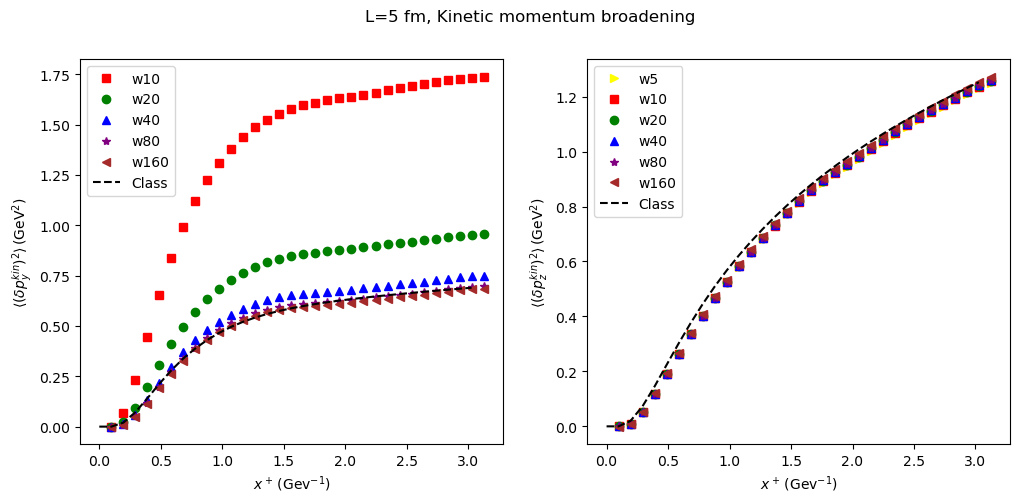

In [25]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w5, '>', label='w5', color='yellow')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w10, 's', label='w10', color='red')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w20, 'o', label='w20', color='green')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w40, '^', label='w40', color='blue')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w80, '*', label='w80', color='purple')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w160, '<', label='w160', color='brown')
axes[0].plot(xp_class*2/0.197326, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w5, '>', label='w5', color='yellow')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w10, 's', label='w10', color='red')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w20, 'o', label='w20', color='green')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w40, '^', label='w40', color='blue')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w80, '*', label='w80', color='purple')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w160, '<', label='w160', color='brown')
axes[1].plot(xp_class*2/0.197326, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=5_plots/Kinetic_momentum_coulomb.pdf', bbox_inches='tight')

In [26]:
# We save the results to file
np.savetxt('paper_plots/direct_pkin.txt', [xplus, delta_pkin_y2_w80 , delta_pkin_z2_w80], fmt='%f')

## 5. Lorentz force calculation

We load the quantum results

In [1]:
# We create a list with the files to read

Nevs = 100

delta_pkin_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_Lorentz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_exp_sq_autonomy.dat' %(nev) for nev in range(Nevs)]

In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

delta_pkin_df_list = []

for i in range(Nevs):
    
    delta_pkin_df = pd.read_table(delta_pkin_list[i], header = None)
    delta_pkin_df_list.append(delta_pkin_df)

delta_pkin_data = np.array(delta_pkin_df_list)

In [3]:
# We average over events

delta_pkin_av = np.average(delta_pkin_data, axis=0)
delta_pkin_desv = np.std(delta_pkin_data, axis=0)

In [4]:
# Take the different components of kinetic momentum
xplus = delta_pkin_av[:, 0]

delta_pkin_y = delta_pkin_av[:, 8]
delta_pkin_z = delta_pkin_av[:, 3]

delta_pkin_y_desv = delta_pkin_desv[:, 8]/np.sqrt(Nevs)
delta_pkin_z_desv = delta_pkin_desv[:, 3]/np.sqrt(Nevs)

Load the classical results

In [5]:
# We load the classical result

xp_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[2]

Plot the results

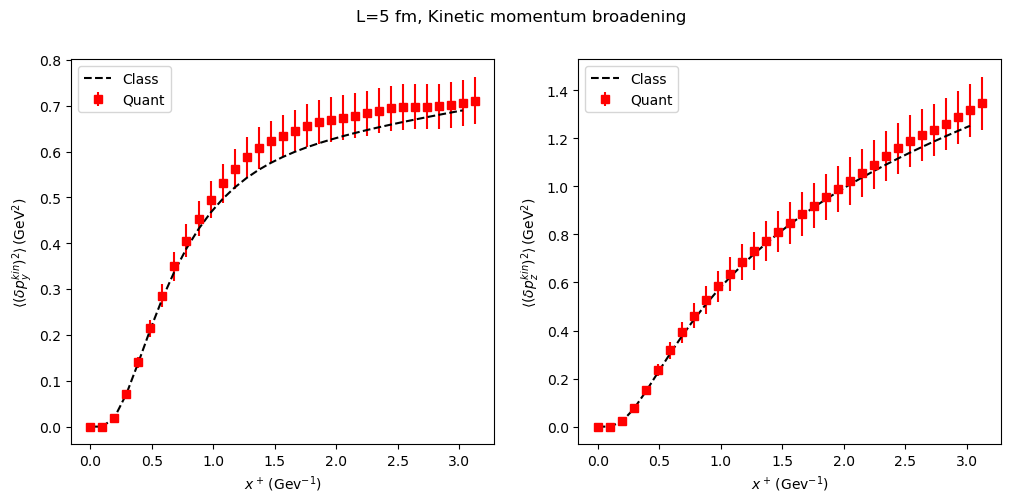

In [8]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(xplus, delta_pkin_y, yerr=delta_pkin_y_desv, fmt='s', label='Quant', color='red')
axes[0].plot(xp_class*2/0.197326, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].errorbar(xplus, delta_pkin_z, yerr=delta_pkin_z_desv, fmt='s', label='Quant', color='red')
axes[1].plot(xp_class*2/0.197326, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=5_plots/Kinetic_momentum_Lorentz.png', bbox_inches='tight')

In [7]:
# We save the results to file
np.savetxt('paper_plots/Lorentz_pkin.txt', [xplus, delta_pkin_y , delta_pkin_z], fmt='%f')

In [11]:
y_rel_err = delta_pkin_y_desv/delta_pkin_y
z_rel_err = delta_pkin_z_desv/delta_pkin_z

print(y_rel_err*100)
print(z_rel_err*100)

[       nan        nan 7.87079603 7.96765366 8.25551427 8.66623281
 8.9972063  9.10646187 8.95201809 8.58825573 8.19844409 7.93776646
 7.78257506 7.63217435 7.45941064 7.29837339 7.18838257 7.14750999
 7.16623206 7.20810063 7.22887534 7.21715284 7.19811969 7.18643556
 7.16880099 7.13059774 7.08240211 7.04956164 7.03966717 7.05312903
 7.10424357 7.19982493 7.32808289]
[        nan         nan 11.72243098 11.34768585 10.96213887 10.83134045
 10.92272399 11.05504624 11.12725774 11.14288019 11.13447737 11.10315789
 11.02443617 10.89616559 10.74426558 10.57812882 10.39825214 10.2162993
 10.0434006   9.89328491  9.77248834  9.66395764  9.54713214  9.42256311
  9.30393393  9.19058667  9.06859328  8.93629898  8.79597869  8.64579851
  8.49817768  8.3742298   8.28063407]


/tmp/ipykernel_1554841/3034827883.py:1: RuntimeWarning: invalid value encountered in true_divide
  y_rel_err = delta_pkin_y_desv/delta_pkin_y
/tmp/ipykernel_1554841/3034827883.py:2: RuntimeWarning: invalid value encountered in true_divide
  z_rel_err = delta_pkin_z_desv/delta_pkin_z


## 6. Check the dependence with the width in $y$

Canonical momentum

In [3]:
# We create a list with the files to read

Nevs = 100

p2_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_5.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_5.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_20.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_20.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_160.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_160.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [4]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_w5 = []; pp0_df_list_w5 = []
p2_df_list_w10 = []; pp0_df_list_w10 = []
p2_df_list_w20 = []; pp0_df_list_w20 = []
p2_df_list_w40 = []; pp0_df_list_w40 = []
p2_df_list_w80 = []; pp0_df_list_w80 = []
p2_df_list_w160 = []; pp0_df_list_w160 = []

for i in range(Nevs):
    
    p2_df_w5 = [pd.read_table(p2_file_list_w5[i], header = None)]
    pp0_df_w5 = [pd.read_table(pp0_file_list_w5[i], header = None)]
    
    p2_df_w10 = [pd.read_table(p2_file_list_w10[i], header = None)]
    pp0_df_w10 = [pd.read_table(pp0_file_list_w10[i], header = None)]
    
    p2_df_w20 = [pd.read_table(p2_file_list_w20[i], header = None)]
    pp0_df_w20 = [pd.read_table(pp0_file_list_w20[i], header = None)]
    
    p2_df_w40 = [pd.read_table(p2_file_list_w40[i], header = None)]
    pp0_df_w40 = [pd.read_table(pp0_file_list_w40[i], header = None)]
    
    p2_df_w80 = [pd.read_table(p2_file_list_w80[i], header = None)]
    pp0_df_w80 = [pd.read_table(pp0_file_list_w80[i], header = None)]
    
    p2_df_w160 = [pd.read_table(p2_file_list_w160[i], header = None)]
    pp0_df_w160 = [pd.read_table(pp0_file_list_w160[i], header = None)]
    
    
    p2_df_list_w5.append(p2_df_w5); pp0_df_list_w5.append(pp0_df_w5)
    p2_df_list_w10.append(p2_df_w10); pp0_df_list_w10.append(pp0_df_w10)
    p2_df_list_w20.append(p2_df_w20); pp0_df_list_w20.append(pp0_df_w20)
    p2_df_list_w40.append(p2_df_w40); pp0_df_list_w40.append(pp0_df_w40)
    p2_df_list_w80.append(p2_df_w80); pp0_df_list_w80.append(pp0_df_w80)
    p2_df_list_w160.append(p2_df_w160); pp0_df_list_w160.append(pp0_df_w160)
    

p2_data_w5 = np.array(p2_df_list_w5); pp0_data_w5 = np.array(pp0_df_list_w5)
p2_data_w10 = np.array(p2_df_list_w10); pp0_data_w10 = np.array(pp0_df_list_w10)
p2_data_w20 = np.array(p2_df_list_w20); pp0_data_w20 = np.array(pp0_df_list_w20)
p2_data_w40 = np.array(p2_df_list_w40); pp0_data_w40 = np.array(pp0_df_list_w40)
p2_data_w80 = np.array(p2_df_list_w80); pp0_data_w80 = np.array(pp0_df_list_w80)
p2_data_w160 = np.array(p2_df_list_w160); pp0_data_w160 = np.array(pp0_df_list_w160)

In [5]:
# We average over events

p2_av_w5 = np.average(p2_data_w5, axis=(0, 1)); pp0_av_w5 = np.average(pp0_data_w5, axis=(0, 1))
p2_av_w10 = np.average(p2_data_w10, axis=(0, 1)); pp0_av_w10 = np.average(pp0_data_w10, axis=(0, 1))
p2_av_w20 = np.average(p2_data_w20, axis=(0, 1)); pp0_av_w20 = np.average(pp0_data_w20, axis=(0, 1))
p2_av_w40 = np.average(p2_data_w40, axis=(0, 1)); pp0_av_w40 = np.average(pp0_data_w40, axis=(0, 1))
p2_av_w80 = np.average(p2_data_w80, axis=(0, 1)); pp0_av_w80 = np.average(pp0_data_w80, axis=(0, 1))
p2_av_w160 = np.average(p2_data_w160, axis=(0, 1)); pp0_av_w160 = np.average(pp0_data_w160, axis=(0, 1))

In [6]:
# Take the different components of canonic momentum
xplus = p2_av_w10[:, 0]

p2_z_w5 = p2_av_w5[:, 1]; p2_y_w5 = p2_av_w5[:, 2]
pp0_z_w5 = pp0_av_w5[:, 1]; pp0_y_w5 = pp0_av_w5[:, 2]

p2_z_w10 = p2_av_w10[:, 1]; p2_y_w10 = p2_av_w10[:, 2]
pp0_z_w10 = pp0_av_w10[:, 1]; pp0_y_w10 = pp0_av_w10[:, 2]

p2_z_w20 = p2_av_w20[:, 1]; p2_y_w20 = p2_av_w20[:, 2]
pp0_z_w20 = pp0_av_w20[:, 1]; pp0_y_w20 = pp0_av_w20[:, 2]

p2_z_w40 = p2_av_w40[:, 1]; p2_y_w40 = p2_av_w40[:, 2]
pp0_z_w40 = pp0_av_w40[:, 1]; pp0_y_w40 = pp0_av_w40[:, 2]

p2_z_w80 = p2_av_w80[:, 1]; p2_y_w80 = p2_av_w80[:, 2]
pp0_z_w80 = pp0_av_w80[:, 1]; pp0_y_w80 = pp0_av_w80[:, 2]

p2_z_w160 = p2_av_w160[:, 1]; p2_y_w160 = p2_av_w160[:, 2]
pp0_z_w160 = pp0_av_w160[:, 1]; pp0_y_w160 = pp0_av_w160[:, 2]

In [7]:
# We compute momentum broadening

delta_p2_y_w5 = p2_y_w5 + p2_y_w5[0] - pp0_y_w5
delta_p2_z_w5 = p2_z_w5 + p2_z_w5[0] - pp0_z_w5

delta_p2_y_w10 = p2_y_w10 + p2_y_w10[0] - pp0_y_w10
delta_p2_z_w10 = p2_z_w10 + p2_z_w10[0] - pp0_z_w10

delta_p2_y_w20 = p2_y_w20 + p2_y_w20[0] - pp0_y_w20
delta_p2_z_w20 = p2_z_w20 + p2_z_w20[0] - pp0_z_w20

delta_p2_y_w40 = p2_y_w40 + p2_y_w40[0] - pp0_y_w40
delta_p2_z_w40 = p2_z_w40 + p2_z_w40[0] - pp0_z_w40

delta_p2_y_w80 = p2_y_w80 + p2_y_w80[0] - pp0_y_w80
delta_p2_z_w80 = p2_z_w80 + p2_z_w80[0] - pp0_z_w80

delta_p2_y_w160 = p2_y_w160 + p2_y_w160[0] - pp0_y_w160
delta_p2_z_w160 = p2_z_w160 + p2_z_w160[0] - pp0_z_w160

Field contribution

In [8]:
# We create a list with the files to read

Nevs = 100

A2_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_5.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_5.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_20.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_20.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_160.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_160.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [9]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_w5 = []; AA0_df_list_w5 = []
A2_df_list_w10 = []; AA0_df_list_w10 = []
A2_df_list_w20 = []; AA0_df_list_w20 = []
A2_df_list_w40 = []; AA0_df_list_w40 = []
A2_df_list_w80 = []; AA0_df_list_w80 = []
A2_df_list_w160 = []; AA0_df_list_w160 = []

for i in range(Nevs):
    
    A2_df_w5 = [pd.read_table(A2_file_list_w5[i], header = None)]
    AA0_df_w5 = [pd.read_table(AA0_file_list_w5[i], header = None)]
    
    A2_df_w10 = [pd.read_table(A2_file_list_w10[i], header = None)]
    AA0_df_w10 = [pd.read_table(AA0_file_list_w10[i], header = None)]
    
    A2_df_w20 = [pd.read_table(A2_file_list_w20[i], header = None)]
    AA0_df_w20 = [pd.read_table(AA0_file_list_w20[i], header = None)]
    
    A2_df_w40 = [pd.read_table(A2_file_list_w40[i], header = None)]
    AA0_df_w40 = [pd.read_table(AA0_file_list_w40[i], header = None)]
    
    A2_df_w80 = [pd.read_table(A2_file_list_w80[i], header = None)]
    AA0_df_w80 = [pd.read_table(AA0_file_list_w80[i], header = None)]
    
    A2_df_w160 = [pd.read_table(A2_file_list_w160[i], header = None)]
    AA0_df_w160 = [pd.read_table(AA0_file_list_w160[i], header = None)]

    A2_df_list_w5.append(A2_df_w5); AA0_df_list_w5.append(AA0_df_w5)
    A2_df_list_w10.append(A2_df_w10); AA0_df_list_w10.append(AA0_df_w10)
    A2_df_list_w20.append(A2_df_w20); AA0_df_list_w20.append(AA0_df_w20)
    A2_df_list_w40.append(A2_df_w40); AA0_df_list_w40.append(AA0_df_w40)
    A2_df_list_w80.append(A2_df_w80); AA0_df_list_w80.append(AA0_df_w80)
    A2_df_list_w160.append(A2_df_w160); AA0_df_list_w160.append(AA0_df_w160)

A2_data_w5 = np.array(A2_df_list_w5); AA0_data_w5 = np.array(AA0_df_list_w5)
A2_data_w10 = np.array(A2_df_list_w10); AA0_data_w10 = np.array(AA0_df_list_w10)
A2_data_w20 = np.array(A2_df_list_w20); AA0_data_w20 = np.array(AA0_df_list_w20)
A2_data_w40 = np.array(A2_df_list_w40); AA0_data_w40 = np.array(AA0_df_list_w40)
A2_data_w80 = np.array(A2_df_list_w80); AA0_data_w80 = np.array(AA0_df_list_w80)
A2_data_w160 = np.array(A2_df_list_w160); AA0_data_w160 = np.array(AA0_df_list_w160)

In [11]:
# We average over events
A2_av_w5 = np.average(A2_data_w5, axis=(0, 1)); AA0_av_w5 = np.average(AA0_data_w5, axis=(0, 1))
A2_av_w10 = np.average(A2_data_w10, axis=(0, 1)); AA0_av_w10 = np.average(AA0_data_w10, axis=(0, 1))
A2_av_w20 = np.average(A2_data_w20, axis=(0, 1)); AA0_av_w20 = np.average(AA0_data_w20, axis=(0, 1))
A2_av_w40 = np.average(A2_data_w40, axis=(0, 1)); AA0_av_w40 = np.average(AA0_data_w40, axis=(0, 1))
A2_av_w80 = np.average(A2_data_w80, axis=(0, 1)); AA0_av_w80 = np.average(AA0_data_w80, axis=(0, 1))
A2_av_w160 = np.average(A2_data_w160, axis=(0, 1)); AA0_av_w160 = np.average(AA0_data_w160, axis=(0, 1))

In [12]:
# Take the different components of canonic momentum
xplus = A2_av_w10[:, 0]

A2_z_w5 = A2_av_w5[:, 2]; A2_y_w5 = A2_av_w5[:, 6]
AA0_z_w5 = AA0_av_w5[:, 1]; AA0_y_w5 = AA0_av_w5[:, 2]

A2_z_w10 = A2_av_w10[:, 2]; A2_y_w10 = A2_av_w10[:, 6]
AA0_z_w10 = AA0_av_w10[:, 1]; AA0_y_w10 = AA0_av_w10[:, 2]

A2_z_w20 = A2_av_w20[:, 2]; A2_y_w20 = A2_av_w20[:, 6]
AA0_z_w20 = AA0_av_w20[:, 1]; AA0_y_w20 = AA0_av_w20[:, 2]

A2_z_w40 = A2_av_w40[:, 2]; A2_y_w40 = A2_av_w40[:, 6]
AA0_z_w40 = AA0_av_w40[:, 1]; AA0_y_w40 = AA0_av_w40[:, 2]

A2_z_w80 = A2_av_w80[:, 2]; A2_y_w80 = A2_av_w80[:, 6]
AA0_z_w80 = AA0_av_w80[:, 1]; AA0_y_w80 = AA0_av_w80[:, 2]

A2_z_w160 = A2_av_w160[:, 2]; A2_y_w160 = A2_av_w160[:, 6]
AA0_z_w160 = AA0_av_w160[:, 1]; AA0_y_w160 = AA0_av_w160[:, 2]

In [13]:
# We compute momentum broadening

delta_A2_y_w5 = A2_y_w5 + A2_y_w5[0] -  AA0_y_w5
delta_A2_z_w5 = A2_z_w5 + A2_z_w5[0] - AA0_z_w5

delta_A2_y_w10 = A2_y_w10 + A2_y_w10[0] -  AA0_y_w10
delta_A2_z_w10 = A2_z_w10 + A2_z_w10[0] - AA0_z_w10

delta_A2_y_w20 = A2_y_w20 + A2_y_w20[0] -  AA0_y_w20
delta_A2_z_w20 = A2_z_w20 + A2_z_w20[0] - AA0_z_w20

delta_A2_y_w40 = A2_y_w40 + A2_y_w40[0] -  AA0_y_w40
delta_A2_z_w40 = A2_z_w40 + A2_z_w40[0] - AA0_z_w40

delta_A2_y_w80 = A2_y_w80 + A2_y_w80[0] -  AA0_y_w80
delta_A2_z_w80 = A2_z_w80 + A2_z_w80[0] - AA0_z_w80

delta_A2_y_w160 = A2_y_w160 + A2_y_w160[0] -  AA0_y_w160
delta_A2_z_w160 = A2_z_w160 + A2_z_w160[0] - AA0_z_w160

Cross term

In [16]:
# We create a list with the files to read

Nevs = 100

pA_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_5.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_5.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_5.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_20.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_20.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_20.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_160.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_160.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]
p0A_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wy/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_160.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [17]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_w5 = []; pA0_df_list_w5 = []; p0A_df_list_w5 = []
pA_df_list_w10 = []; pA0_df_list_w10 = []; p0A_df_list_w10 = []
pA_df_list_w20 = []; pA0_df_list_w20 = []; p0A_df_list_w20 = []
pA_df_list_w40 = []; pA0_df_list_w40 = []; p0A_df_list_w40 = []
pA_df_list_w80 = []; pA0_df_list_w80 = []; p0A_df_list_w80 = []
pA_df_list_w160 = []; pA0_df_list_w160 = []; p0A_df_list_w160 = []

for i in range(Nevs):
    
    pA_df_w5 = [pd.read_table(pA_file_list_w5[i], header = None)]
    pA0_df_w5 = [pd.read_table(pA0_file_list_w5[i], header = None)]
    p0A_df_w5 = [pd.read_table(p0A_file_list_w5[i], header = None)]
    
    pA_df_w10 = [pd.read_table(pA_file_list_w10[i], header = None)]
    pA0_df_w10 = [pd.read_table(pA0_file_list_w10[i], header = None)]
    p0A_df_w10 = [pd.read_table(p0A_file_list_w10[i], header = None)]
    
    pA_df_w20 = [pd.read_table(pA_file_list_w20[i], header = None)]
    pA0_df_w20 = [pd.read_table(pA0_file_list_w20[i], header = None)]
    p0A_df_w20 = [pd.read_table(p0A_file_list_w20[i], header = None)]
    
    pA_df_w40 = [pd.read_table(pA_file_list_w40[i], header = None)]
    pA0_df_w40 = [pd.read_table(pA0_file_list_w40[i], header = None)]
    p0A_df_w40 = [pd.read_table(p0A_file_list_w40[i], header = None)]
    
    pA_df_w80 = [pd.read_table(pA_file_list_w80[i], header = None)]
    pA0_df_w80 = [pd.read_table(pA0_file_list_w80[i], header = None)]
    p0A_df_w80 = [pd.read_table(p0A_file_list_w80[i], header = None)]
    
    pA_df_w160 = [pd.read_table(pA_file_list_w160[i], header = None)]
    pA0_df_w160 = [pd.read_table(pA0_file_list_w160[i], header = None)]
    p0A_df_w160 = [pd.read_table(p0A_file_list_w160[i], header = None)]
    
    pA_df_list_w5.append(pA_df_w5); pA0_df_list_w5.append(pA0_df_w5); p0A_df_list_w5.append(p0A_df_w5)
    pA_df_list_w10.append(pA_df_w10); pA0_df_list_w10.append(pA0_df_w10); p0A_df_list_w10.append(p0A_df_w10)
    pA_df_list_w20.append(pA_df_w20); pA0_df_list_w20.append(pA0_df_w20); p0A_df_list_w20.append(p0A_df_w20)
    pA_df_list_w40.append(pA_df_w40); pA0_df_list_w40.append(pA0_df_w40); p0A_df_list_w40.append(p0A_df_w40)
    pA_df_list_w80.append(pA_df_w80); pA0_df_list_w80.append(pA0_df_w80); p0A_df_list_w80.append(p0A_df_w80)
    pA_df_list_w160.append(pA_df_w160); pA0_df_list_w160.append(pA0_df_w160); p0A_df_list_w160.append(p0A_df_w160)

pA_data_w5 = np.array(pA_df_list_w5); pA0_data_w5 = np.array(pA0_df_list_w5); p0A_data_w5 = np.array(p0A_df_list_w5)
pA_data_w10 = np.array(pA_df_list_w10); pA0_data_w10 = np.array(pA0_df_list_w10); p0A_data_w10 = np.array(p0A_df_list_w10)
pA_data_w20 = np.array(pA_df_list_w20); pA0_data_w20 = np.array(pA0_df_list_w20); p0A_data_w20 = np.array(p0A_df_list_w20)
pA_data_w40 = np.array(pA_df_list_w40); pA0_data_w40 = np.array(pA0_df_list_w40); p0A_data_w40 = np.array(p0A_df_list_w40)
pA_data_w80 = np.array(pA_df_list_w80); pA0_data_w80 = np.array(pA0_df_list_w80); p0A_data_w80 = np.array(p0A_df_list_w80)
pA_data_w160 = np.array(pA_df_list_w160); pA0_data_w160 = np.array(pA0_df_list_w160); p0A_data_w160 = np.array(p0A_df_list_w160)

In [19]:
# We average over events

pA_av_w5 = np.average(pA_data_w5, axis=(0, 1)); pA0_av_w5 = np.average(pA0_data_w5, axis=(0, 1)); p0A_av_w5 = np.average(p0A_data_w5, axis=(0, 1))
pA_av_w10 = np.average(pA_data_w10, axis=(0, 1)); pA0_av_w10 = np.average(pA0_data_w10, axis=(0, 1)); p0A_av_w10 = np.average(p0A_data_w10, axis=(0, 1))
pA_av_w20 = np.average(pA_data_w20, axis=(0, 1)); pA0_av_w20 = np.average(pA0_data_w20, axis=(0, 1)); p0A_av_w20 = np.average(p0A_data_w20, axis=(0, 1))
pA_av_w40 = np.average(pA_data_w40, axis=(0, 1)); pA0_av_w40 = np.average(pA0_data_w40, axis=(0, 1)); p0A_av_w40 = np.average(p0A_data_w40, axis=(0, 1))
pA_av_w80 = np.average(pA_data_w80, axis=(0, 1)); pA0_av_w80 = np.average(pA0_data_w80, axis=(0, 1)); p0A_av_w80 = np.average(p0A_data_w80, axis=(0, 1))
pA_av_w160 = np.average(pA_data_w160, axis=(0, 1)); pA0_av_w160 = np.average(pA0_data_w160, axis=(0, 1)); p0A_av_w160 = np.average(p0A_data_w160, axis=(0, 1))

In [20]:
# Take the different components of canonic momentum
xplus = pA_av_w10[:, 0]

pA_z_w5 = pA_av_w5[:, 3]; pA_y_w5 = pA_av_w5[:, 7]
pA0_z_w5 = pA0_av_w5[:, 1]; pA0_y_w5 = pA0_av_w5[:, 2]
p0A_z_w5 = p0A_av_w5[:, 1]; p0A_y_w5 = p0A_av_w5[:, 2]

pA_z_w10 = pA_av_w10[:, 3]; pA_y_w10 = pA_av_w10[:, 7]
pA0_z_w10 = pA0_av_w10[:, 1]; pA0_y_w10 = pA0_av_w10[:, 2]
p0A_z_w10 = p0A_av_w10[:, 1]; p0A_y_w10 = p0A_av_w10[:, 2]

pA_z_w20 = pA_av_w20[:, 3]; pA_y_w20 = pA_av_w20[:, 7]
pA0_z_w20 = pA0_av_w20[:, 1]; pA0_y_w20 = pA0_av_w20[:, 2]
p0A_z_w20 = p0A_av_w20[:, 1]; p0A_y_w20 = p0A_av_w20[:, 2]

pA_z_w40 = pA_av_w40[:, 3]; pA_y_w40 = pA_av_w40[:, 7]
pA0_z_w40 = pA0_av_w40[:, 1]; pA0_y_w40 = pA0_av_w40[:, 2]
p0A_z_w40 = p0A_av_w40[:, 1]; p0A_y_w40 = p0A_av_w40[:, 2]

pA_z_w80 = pA_av_w80[:, 3]; pA_y_w80 = pA_av_w80[:, 7]
pA0_z_w80 = pA0_av_w80[:, 1]; pA0_y_w80 = pA0_av_w80[:, 2]
p0A_z_w80 = p0A_av_w80[:, 1]; p0A_y_w80 = p0A_av_w80[:, 2]

pA_z_w160 = pA_av_w160[:, 3]; pA_y_w160 = pA_av_w160[:, 7]
pA0_z_w160 = pA0_av_w160[:, 1]; pA0_y_w160 = pA0_av_w160[:, 2]
p0A_z_w160 = p0A_av_w160[:, 1]; p0A_y_w160 = p0A_av_w160[:, 2]

In [21]:
# We compute momentum broadening

delta_pA_y_w5 = pA_y_w5 + pA_y_w5[0] -  pA0_y_w5 - p0A_y_w5
delta_pA_z_w5 = pA_z_w5 + pA_z_w5[0] -  pA0_z_w5 - p0A_z_w5

delta_pA_y_w10 = pA_y_w10 + pA_y_w10[0] -  pA0_y_w10 - p0A_y_w10
delta_pA_z_w10 = pA_z_w10 + pA_z_w10[0] -  pA0_z_w10 - p0A_z_w10

delta_pA_y_w20 = pA_y_w20 + pA_y_w20[0] -  pA0_y_w20 - p0A_y_w20
delta_pA_z_w20 = pA_z_w20 + pA_z_w20[0] -  pA0_z_w20 - p0A_z_w20

delta_pA_y_w40 = pA_y_w40 + pA_y_w40[0] -  pA0_y_w40 - p0A_y_w40
delta_pA_z_w40 = pA_z_w40 + pA_z_w40[0] -  pA0_z_w40 - p0A_z_w40

delta_pA_y_w80 = pA_y_w80 + pA_y_w80[0] -  pA0_y_w80 - p0A_y_w80
delta_pA_z_w80 = pA_z_w80 + pA_z_w80[0] -  pA0_z_w80 - p0A_z_w80

delta_pA_y_w160 = pA_y_w160 + pA_y_w160[0] -  pA0_y_w160 - p0A_y_w160
delta_pA_z_w160 = pA_z_w160 + pA_z_w160[0] -  pA0_z_w160 - p0A_z_w160

Compute Kinetic momentum broadening

In [22]:
# We compute the quantum result

delta_pkin_y2_w5 = delta_p2_y_w5 + delta_A2_y_w5 + delta_pA_y_w5
delta_pkin_z2_w5 = delta_p2_z_w5 + delta_A2_z_w5 + delta_pA_z_w5

delta_pkin_y2_w10 = delta_p2_y_w10 + delta_A2_y_w10 + delta_pA_y_w10
delta_pkin_z2_w10 = delta_p2_z_w10 + delta_A2_z_w10 + delta_pA_z_w10

delta_pkin_y2_w20 = delta_p2_y_w20 + delta_A2_y_w20 + delta_pA_y_w20
delta_pkin_z2_w20 = delta_p2_z_w20 + delta_A2_z_w20 + delta_pA_z_w20

delta_pkin_y2_w40 = delta_p2_y_w40 + delta_A2_y_w40 + delta_pA_y_w40
delta_pkin_z2_w40 = delta_p2_z_w40 + delta_A2_z_w40 + delta_pA_z_w40

delta_pkin_y2_w80 = delta_p2_y_w80 + delta_A2_y_w80 + delta_pA_y_w80
delta_pkin_z2_w80 = delta_p2_z_w80 + delta_A2_z_w80 + delta_pA_z_w80

delta_pkin_y2_w160 = delta_p2_y_w160 + delta_A2_y_w160 + delta_pA_y_w160
delta_pkin_z2_w160 = delta_p2_z_w160 + delta_A2_z_w160 + delta_pA_z_w160

Load the classical results

In [24]:
# We load the classical result

xp_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[2]

Plot the results

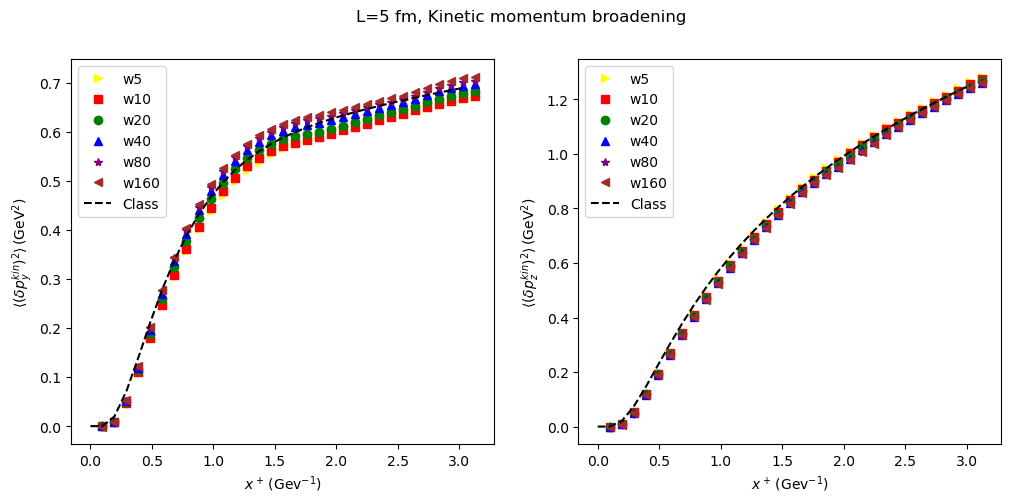

In [26]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w5, '>', label='w5', color='yellow')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w10, 's', label='w10', color='red')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w20, 'o', label='w20', color='green')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w40, '^', label='w40', color='blue')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w80, '*', label='w80', color='purple')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w160, '<', label='w160', color='brown')
axes[0].plot(xp_class*2/0.197326, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w5, '>', label='w5', color='yellow')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w10, 's', label='w10', color='red')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w20, 'o', label='w20', color='green')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w40, '^', label='w40', color='blue')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w80, '*', label='w80', color='purple')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w160, '<', label='w160', color='brown')
axes[1].plot(xp_class*2/0.197326, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=5_plots/Kinetic_momentum_coulomb.pdf', bbox_inches='tight')

In [27]:
# We save the results

np.savetxt('paper_plots/pkin_wy5.txt', [xplus, delta_pkin_y2_w5 , delta_pkin_z2_w5], fmt='%f')
np.savetxt('paper_plots/pkin_wy10.txt', [xplus, delta_pkin_y2_w10 , delta_pkin_z2_w10], fmt='%f')
np.savetxt('paper_plots/pkin_wy20.txt', [xplus, delta_pkin_y2_w20 , delta_pkin_z2_w20], fmt='%f')
np.savetxt('paper_plots/pkin_wy40.txt', [xplus, delta_pkin_y2_w40 , delta_pkin_z2_w40], fmt='%f')
np.savetxt('paper_plots/pkin_wy80.txt', [xplus, delta_pkin_y2_w80 , delta_pkin_z2_w80], fmt='%f')
np.savetxt('paper_plots/pkin_wy160.txt', [xplus, delta_pkin_y2_w160 , delta_pkin_z2_w160], fmt='%f')

## 7. Check the dependence with the width in $z$

Canonical momentum

In [1]:
# We create a list with the files to read

Nevs = 100

p2_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]


p2_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]


In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_w5 = []; pp0_df_list_w5 = []
p2_df_list_w10 = []; pp0_df_list_w10 = []
p2_df_list_w20 = []; pp0_df_list_w20 = []
p2_df_list_w40 = []; pp0_df_list_w40 = []
p2_df_list_w80 = []; pp0_df_list_w80 = []
p2_df_list_w160 = []; pp0_df_list_w160 = []
for i in range(Nevs):
    
    p2_df_w5 = [pd.read_table(p2_file_list_w5[i], header = None)]
    pp0_df_w5 = [pd.read_table(pp0_file_list_w5[i], header = None)]
    
    p2_df_w10 = [pd.read_table(p2_file_list_w10[i], header = None)]
    pp0_df_w10 = [pd.read_table(pp0_file_list_w10[i], header = None)]
    
    p2_df_w20 = [pd.read_table(p2_file_list_w20[i], header = None)]
    pp0_df_w20 = [pd.read_table(pp0_file_list_w20[i], header = None)]
    
    p2_df_w40 = [pd.read_table(p2_file_list_w40[i], header = None)]
    pp0_df_w40 = [pd.read_table(pp0_file_list_w40[i], header = None)]
    
    p2_df_w80 = [pd.read_table(p2_file_list_w80[i], header = None)]
    pp0_df_w80 = [pd.read_table(pp0_file_list_w80[i], header = None)]
    
    p2_df_w160 = [pd.read_table(p2_file_list_w160[i], header = None)]
    pp0_df_w160 = [pd.read_table(pp0_file_list_w160[i], header = None)]
    
    
    p2_df_list_w5.append(p2_df_w5); pp0_df_list_w5.append(pp0_df_w5)
    p2_df_list_w10.append(p2_df_w10); pp0_df_list_w10.append(pp0_df_w10)
    p2_df_list_w20.append(p2_df_w20); pp0_df_list_w20.append(pp0_df_w20)
    p2_df_list_w40.append(p2_df_w40); pp0_df_list_w40.append(pp0_df_w40)
    p2_df_list_w80.append(p2_df_w80); pp0_df_list_w80.append(pp0_df_w80)
    p2_df_list_w160.append(p2_df_w160); pp0_df_list_w160.append(pp0_df_w160)
    
p2_data_w5 = np.array(p2_df_list_w5); pp0_data_w5 = np.array(pp0_df_list_w5)
p2_data_w10 = np.array(p2_df_list_w10); pp0_data_w10 = np.array(pp0_df_list_w10)
p2_data_w20 = np.array(p2_df_list_w20); pp0_data_w20 = np.array(pp0_df_list_w20)
p2_data_w40 = np.array(p2_df_list_w40); pp0_data_w40 = np.array(pp0_df_list_w40)
p2_data_w80 = np.array(p2_df_list_w80); pp0_data_w80 = np.array(pp0_df_list_w80)
p2_data_w160 = np.array(p2_df_list_w160); pp0_data_w160 = np.array(pp0_df_list_w160)

In [3]:
# We average over events
p2_av_5 = np.average(p2_data_w5, axis=(0, 1)); pp0_av_w5 = np.average(pp0_data_w5, axis=(0, 1))
p2_av_10 = np.average(p2_data_w10, axis=(0, 1)); pp0_av_w10 = np.average(pp0_data_w10, axis=(0, 1))
p2_av_20 = np.average(p2_data_w20, axis=(0, 1)); pp0_av_w20 = np.average(pp0_data_w20, axis=(0, 1))
p2_av_40 = np.average(p2_data_w40, axis=(0, 1)); pp0_av_w40 = np.average(pp0_data_w40, axis=(0, 1))
p2_av_80 = np.average(p2_data_w80, axis=(0, 1)); pp0_av_w80 = np.average(pp0_data_w80, axis=(0, 1))
p2_av_160 = np.average(p2_data_w160, axis=(0, 1)); pp0_av_w160 = np.average(pp0_data_w160, axis=(0, 1))

In [4]:
# Take the different components of canonic momentum
xplus = p2_av_10[:, 0]

p2_z_w5 = p2_av_5[:, 1]; p2_y_w5 = p2_av_5[:, 2]
pp0_z_w5 = pp0_av_w5[:, 1]; pp0_y_w5 = pp0_av_w5[:, 2]

p2_z_w10 = p2_av_10[:, 1]; p2_y_w10 = p2_av_10[:, 2]
pp0_z_w10 = pp0_av_w10[:, 1]; pp0_y_w10 = pp0_av_w10[:, 2]

p2_z_w20 = p2_av_20[:, 1]; p2_y_w20 = p2_av_20[:, 2]
pp0_z_w20 = pp0_av_w20[:, 1]; pp0_y_w20 = pp0_av_w20[:, 2]

p2_z_w40 = p2_av_40[:, 1]; p2_y_w40 = p2_av_40[:, 2]
pp0_z_w40 = pp0_av_w40[:, 1]; pp0_y_w40 = pp0_av_w40[:, 2]

p2_z_w80 = p2_av_80[:, 1]; p2_y_w80 = p2_av_80[:, 2]
pp0_z_w80 = pp0_av_w80[:, 1]; pp0_y_w80 = pp0_av_w80[:, 2]

p2_z_w160 = p2_av_160[:, 1]; p2_y_w160 = p2_av_160[:, 2]
pp0_z_w160 = pp0_av_w160[:, 1]; pp0_y_w160 = pp0_av_w160[:, 2]

In [5]:
# We compute momentum broadening

delta_p2_y_w5 = p2_y_w5 + p2_y_w5[0] - pp0_y_w5
delta_p2_z_w5 = p2_z_w5 + p2_z_w5[0] - pp0_z_w5

delta_p2_y_w10 = p2_y_w10 + p2_y_w10[0] - pp0_y_w10
delta_p2_z_w10 = p2_z_w10 + p2_z_w10[0] - pp0_z_w10

delta_p2_y_w20 = p2_y_w20 + p2_y_w20[0] - pp0_y_w20
delta_p2_z_w20 = p2_z_w20 + p2_z_w20[0] - pp0_z_w20

delta_p2_y_w40 = p2_y_w40 + p2_y_w40[0] - pp0_y_w40
delta_p2_z_w40 = p2_z_w40 + p2_z_w40[0] - pp0_z_w40

delta_p2_y_w80 = p2_y_w80 + p2_y_w80[0] - pp0_y_w80
delta_p2_z_w80 = p2_z_w80 + p2_z_w80[0] - pp0_z_w80

delta_p2_y_w160 = p2_y_w160 + p2_y_w160[0] - pp0_y_w160
delta_p2_z_w160 = p2_z_w160 + p2_z_w160[0] - pp0_z_w160

Field contribution

In [6]:
# We create a list with the files to read

Nevs = 100

A2_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]


In [7]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_w5 = []; AA0_df_list_w5 = []
A2_df_list_w10 = []; AA0_df_list_w10 = []
A2_df_list_w20 = []; AA0_df_list_w20 = []
A2_df_list_w40 = []; AA0_df_list_w40 = []
A2_df_list_w80 = []; AA0_df_list_w80 = []
A2_df_list_w160 = []; AA0_df_list_w160 = []

for i in range(Nevs):
    
    A2_df_w5 = [pd.read_table(A2_file_list_w5[i], header = None)]
    AA0_df_w5 = [pd.read_table(AA0_file_list_w5[i], header = None)]
    
    A2_df_w10 = [pd.read_table(A2_file_list_w10[i], header = None)]
    AA0_df_w10 = [pd.read_table(AA0_file_list_w10[i], header = None)]
    
    A2_df_w20 = [pd.read_table(A2_file_list_w20[i], header = None)]
    AA0_df_w20 = [pd.read_table(AA0_file_list_w20[i], header = None)]
    
    A2_df_w40 = [pd.read_table(A2_file_list_w40[i], header = None)]
    AA0_df_w40 = [pd.read_table(AA0_file_list_w40[i], header = None)]
    
    A2_df_w80 = [pd.read_table(A2_file_list_w80[i], header = None)]
    AA0_df_w80 = [pd.read_table(AA0_file_list_w80[i], header = None)]
    
    A2_df_w160 = [pd.read_table(A2_file_list_w160[i], header = None)]
    AA0_df_w160 = [pd.read_table(AA0_file_list_w160[i], header = None)]
    
    A2_df_list_w5.append(A2_df_w5); AA0_df_list_w5.append(AA0_df_w5)
    A2_df_list_w10.append(A2_df_w10); AA0_df_list_w10.append(AA0_df_w10)
    A2_df_list_w20.append(A2_df_w20); AA0_df_list_w20.append(AA0_df_w20)
    A2_df_list_w40.append(A2_df_w40); AA0_df_list_w40.append(AA0_df_w40)
    A2_df_list_w80.append(A2_df_w80); AA0_df_list_w80.append(AA0_df_w80)
    A2_df_list_w160.append(A2_df_w160); AA0_df_list_w160.append(AA0_df_w160)

A2_data_w5 = np.array(A2_df_list_w5); AA0_data_w5 = np.array(AA0_df_list_w5)
A2_data_w10 = np.array(A2_df_list_w10); AA0_data_w10 = np.array(AA0_df_list_w10)
A2_data_w20 = np.array(A2_df_list_w20); AA0_data_w20 = np.array(AA0_df_list_w20)
A2_data_w40 = np.array(A2_df_list_w40); AA0_data_w40 = np.array(AA0_df_list_w40)
A2_data_w80 = np.array(A2_df_list_w80); AA0_data_w80 = np.array(AA0_df_list_w80)
A2_data_w160 = np.array(A2_df_list_w160); AA0_data_w160 = np.array(AA0_df_list_w160)

In [8]:
# We average over events
A2_av_w5 = np.average(A2_data_w5, axis=(0, 1)); AA0_av_w5 = np.average(AA0_data_w5, axis=(0, 1))
A2_av_w10 = np.average(A2_data_w10, axis=(0, 1)); AA0_av_w10 = np.average(AA0_data_w10, axis=(0, 1))
A2_av_w20 = np.average(A2_data_w20, axis=(0, 1)); AA0_av_w20 = np.average(AA0_data_w20, axis=(0, 1))
A2_av_w40 = np.average(A2_data_w40, axis=(0, 1)); AA0_av_w40 = np.average(AA0_data_w40, axis=(0, 1))
A2_av_w80 = np.average(A2_data_w80, axis=(0, 1)); AA0_av_w80 = np.average(AA0_data_w80, axis=(0, 1))
A2_av_w160 = np.average(A2_data_w160, axis=(0, 1)); AA0_av_w160 = np.average(AA0_data_w160, axis=(0, 1))

In [9]:
# Take the different components of canonic momentum
xplus = A2_av_w10[:, 0]

A2_z_w5 = A2_av_w5[:, 2]; A2_y_w5 = A2_av_w5[:, 6]
AA0_z_w5 = AA0_av_w5[:, 1]; AA0_y_w5 = AA0_av_w5[:, 2]

A2_z_w10 = A2_av_w10[:, 2]; A2_y_w10 = A2_av_w10[:, 6]
AA0_z_w10 = AA0_av_w10[:, 1]; AA0_y_w10 = AA0_av_w10[:, 2]

A2_z_w20 = A2_av_w20[:, 2]; A2_y_w20 = A2_av_w20[:, 6]
AA0_z_w20 = AA0_av_w20[:, 1]; AA0_y_w20 = AA0_av_w20[:, 2]

A2_z_w40 = A2_av_w40[:, 2]; A2_y_w40 = A2_av_w40[:, 6]
AA0_z_w40 = AA0_av_w40[:, 1]; AA0_y_w40 = AA0_av_w40[:, 2]

A2_z_w80 = A2_av_w80[:, 2]; A2_y_w80 = A2_av_w80[:, 6]
AA0_z_w80 = AA0_av_w80[:, 1]; AA0_y_w80 = AA0_av_w80[:, 2]

A2_z_w160 = A2_av_w160[:, 2]; A2_y_w160 = A2_av_w160[:, 6]
AA0_z_w160 = AA0_av_w160[:, 1]; AA0_y_w160 = AA0_av_w160[:, 2]

In [10]:
# We compute momentum broadening

delta_A2_y_w5 = A2_y_w5 + A2_y_w5[0] -  AA0_y_w5
delta_A2_z_w5 = A2_z_w5 + A2_z_w5[0] - AA0_z_w5

delta_A2_y_w10 = A2_y_w10 + A2_y_w10[0] -  AA0_y_w10
delta_A2_z_w10 = A2_z_w10 + A2_z_w10[0] - AA0_z_w10

delta_A2_y_w20 = A2_y_w20 + A2_y_w20[0] -  AA0_y_w20
delta_A2_z_w20 = A2_z_w20 + A2_z_w20[0] - AA0_z_w20

delta_A2_y_w40 = A2_y_w40 + A2_y_w40[0] -  AA0_y_w40
delta_A2_z_w40 = A2_z_w40 + A2_z_w40[0] - AA0_z_w40

delta_A2_y_w80 = A2_y_w80 + A2_y_w80[0] -  AA0_y_w80
delta_A2_z_w80 = A2_z_w80 + A2_z_w80[0] - AA0_z_w80

delta_A2_y_w160 = A2_y_w160 + A2_y_w160[0] -  AA0_y_w160
delta_A2_z_w160 = A2_z_w160 + A2_z_w160[0] - AA0_z_w160

Cross terms

In [11]:
# We create a list with the files to read

Nevs = 100

pA_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w5 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_5.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w10 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w20 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_20.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w40 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_40.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w80 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_w160 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_wz/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_160.000000_wy_40.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_25_Nperp_512_Leta_3.125000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [12]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_w5 = []; pA0_df_list_w5 = []; p0A_df_list_w5 = []
pA_df_list_w10 = []; pA0_df_list_w10 = []; p0A_df_list_w10 = []
pA_df_list_w20 = []; pA0_df_list_w20 = []; p0A_df_list_w20 = []
pA_df_list_w40 = []; pA0_df_list_w40 = []; p0A_df_list_w40 = []
pA_df_list_w80 = []; pA0_df_list_w80 = []; p0A_df_list_w80 = []
pA_df_list_w160 = []; pA0_df_list_w160 = []; p0A_df_list_w160 = []
for i in range(Nevs):
    
    pA_df_w5 = [pd.read_table(pA_file_list_w5[i], header = None)]
    pA0_df_w5 = [pd.read_table(pA0_file_list_w5[i], header = None)]
    p0A_df_w5 = [pd.read_table(p0A_file_list_w5[i], header = None)]
    
    pA_df_w10 = [pd.read_table(pA_file_list_w10[i], header = None)]
    pA0_df_w10 = [pd.read_table(pA0_file_list_w10[i], header = None)]
    p0A_df_w10 = [pd.read_table(p0A_file_list_w10[i], header = None)]
    
    pA_df_w20 = [pd.read_table(pA_file_list_w20[i], header = None)]
    pA0_df_w20 = [pd.read_table(pA0_file_list_w20[i], header = None)]
    p0A_df_w20 = [pd.read_table(p0A_file_list_w20[i], header = None)]
    
    pA_df_w40 = [pd.read_table(pA_file_list_w40[i], header = None)]
    pA0_df_w40 = [pd.read_table(pA0_file_list_w40[i], header = None)]
    p0A_df_w40 = [pd.read_table(p0A_file_list_w40[i], header = None)]
    
    pA_df_w80 = [pd.read_table(pA_file_list_w80[i], header = None)]
    pA0_df_w80 = [pd.read_table(pA0_file_list_w80[i], header = None)]
    p0A_df_w80 = [pd.read_table(p0A_file_list_w80[i], header = None)]
    
    pA_df_w160 = [pd.read_table(pA_file_list_w160[i], header = None)]
    pA0_df_w160 = [pd.read_table(pA0_file_list_w160[i], header = None)]
    p0A_df_w160 = [pd.read_table(p0A_file_list_w160[i], header = None)]
    
    pA_df_list_w5.append(pA_df_w5); pA0_df_list_w5.append(pA0_df_w5); p0A_df_list_w5.append(p0A_df_w5)
    pA_df_list_w10.append(pA_df_w10); pA0_df_list_w10.append(pA0_df_w10); p0A_df_list_w10.append(p0A_df_w10)
    pA_df_list_w20.append(pA_df_w20); pA0_df_list_w20.append(pA0_df_w20); p0A_df_list_w20.append(p0A_df_w20)
    pA_df_list_w40.append(pA_df_w40); pA0_df_list_w40.append(pA0_df_w40); p0A_df_list_w40.append(p0A_df_w40)
    pA_df_list_w80.append(pA_df_w80); pA0_df_list_w80.append(pA0_df_w80); p0A_df_list_w80.append(p0A_df_w80)
    pA_df_list_w160.append(pA_df_w160); pA0_df_list_w160.append(pA0_df_w160); p0A_df_list_w160.append(p0A_df_w160)

pA_data_w5 = np.array(pA_df_list_w5); pA0_data_w5 = np.array(pA0_df_list_w5); p0A_data_w5 = np.array(p0A_df_list_w5)
pA_data_w10 = np.array(pA_df_list_w10); pA0_data_w10 = np.array(pA0_df_list_w10); p0A_data_w10 = np.array(p0A_df_list_w10)
pA_data_w20 = np.array(pA_df_list_w20); pA0_data_w20 = np.array(pA0_df_list_w20); p0A_data_w20 = np.array(p0A_df_list_w20)
pA_data_w40 = np.array(pA_df_list_w40); pA0_data_w40 = np.array(pA0_df_list_w40); p0A_data_w40 = np.array(p0A_df_list_w40)
pA_data_w80 = np.array(pA_df_list_w80); pA0_data_w80 = np.array(pA0_df_list_w80); p0A_data_w80 = np.array(p0A_df_list_w80)
pA_data_w160 = np.array(pA_df_list_w160); pA0_data_w160 = np.array(pA0_df_list_w160); p0A_data_w160 = np.array(p0A_df_list_w160)

In [13]:
# We average over events
pA_av_w5 = np.average(pA_data_w5, axis=(0, 1)); pA0_av_w5 = np.average(pA0_data_w5, axis=(0, 1)); p0A_av_w5 = np.average(p0A_data_w5, axis=(0, 1))
pA_av_w10 = np.average(pA_data_w10, axis=(0, 1)); pA0_av_w10 = np.average(pA0_data_w10, axis=(0, 1)); p0A_av_w10 = np.average(p0A_data_w10, axis=(0, 1))
pA_av_w20 = np.average(pA_data_w20, axis=(0, 1)); pA0_av_w20 = np.average(pA0_data_w20, axis=(0, 1)); p0A_av_w20 = np.average(p0A_data_w20, axis=(0, 1))
pA_av_w40 = np.average(pA_data_w40, axis=(0, 1)); pA0_av_w40 = np.average(pA0_data_w40, axis=(0, 1)); p0A_av_w40 = np.average(p0A_data_w40, axis=(0, 1))
pA_av_w80 = np.average(pA_data_w80, axis=(0, 1)); pA0_av_w80 = np.average(pA0_data_w80, axis=(0, 1)); p0A_av_w80 = np.average(p0A_data_w80, axis=(0, 1))
pA_av_w160 = np.average(pA_data_w160, axis=(0, 1)); pA0_av_w160 = np.average(pA0_data_w160, axis=(0, 1)); p0A_av_w160 = np.average(p0A_data_w160, axis=(0, 1))

In [14]:
# Take the different components of canonic momentum
xplus = pA_av_w10[:, 0]

pA_z_w5 = pA_av_w5[:, 3]; pA_y_w5 = pA_av_w5[:, 7]
pA0_z_w5 = pA0_av_w5[:, 1]; pA0_y_w5 = pA0_av_w5[:, 2]
p0A_z_w5 = p0A_av_w5[:, 1]; p0A_y_w5 = p0A_av_w5[:, 2]

pA_z_w10 = pA_av_w10[:, 3]; pA_y_w10 = pA_av_w10[:, 7]
pA0_z_w10 = pA0_av_w10[:, 1]; pA0_y_w10 = pA0_av_w10[:, 2]
p0A_z_w10 = p0A_av_w10[:, 1]; p0A_y_w10 = p0A_av_w10[:, 2]

pA_z_w20 = pA_av_w20[:, 3]; pA_y_w20 = pA_av_w20[:, 7]
pA0_z_w20 = pA0_av_w20[:, 1]; pA0_y_w20 = pA0_av_w20[:, 2]
p0A_z_w20 = p0A_av_w20[:, 1]; p0A_y_w20 = p0A_av_w20[:, 2]

pA_z_w40 = pA_av_w40[:, 3]; pA_y_w40 = pA_av_w40[:, 7]
pA0_z_w40 = pA0_av_w40[:, 1]; pA0_y_w40 = pA0_av_w40[:, 2]
p0A_z_w40 = p0A_av_w40[:, 1]; p0A_y_w40 = p0A_av_w40[:, 2]

pA_z_w80 = pA_av_w80[:, 3]; pA_y_w80 = pA_av_w80[:, 7]
pA0_z_w80 = pA0_av_w80[:, 1]; pA0_y_w80 = pA0_av_w80[:, 2]
p0A_z_w80 = p0A_av_w80[:, 1]; p0A_y_w80 = p0A_av_w80[:, 2]

pA_z_w160 = pA_av_w160[:, 3]; pA_y_w160 = pA_av_w160[:, 7]
pA0_z_w160 = pA0_av_w160[:, 1]; pA0_y_w160 = pA0_av_w160[:, 2]
p0A_z_w160 = p0A_av_w160[:, 1]; p0A_y_w160 = p0A_av_w160[:, 2]

In [15]:
# We compute momentum broadening

delta_pA_y_w5 = pA_y_w5 + pA_y_w5[0] -  pA0_y_w5 - p0A_y_w5
delta_pA_z_w5 = pA_z_w5 + pA_z_w5[0] -  pA0_z_w5 - p0A_z_w5

delta_pA_y_w10 = pA_y_w10 + pA_y_w10[0] -  pA0_y_w10 - p0A_y_w10
delta_pA_z_w10 = pA_z_w10 + pA_z_w10[0] -  pA0_z_w10 - p0A_z_w10

delta_pA_y_w20 = pA_y_w20 + pA_y_w20[0] -  pA0_y_w20 - p0A_y_w20
delta_pA_z_w20 = pA_z_w20 + pA_z_w20[0] -  pA0_z_w20 - p0A_z_w20

delta_pA_y_w40 = pA_y_w40 + pA_y_w40[0] -  pA0_y_w40 - p0A_y_w40
delta_pA_z_w40 = pA_z_w40 + pA_z_w40[0] -  pA0_z_w40 - p0A_z_w40

delta_pA_y_w80 = pA_y_w80 + pA_y_w80[0] -  pA0_y_w80 - p0A_y_w80
delta_pA_z_w80 = pA_z_w80 + pA_z_w80[0] -  pA0_z_w80 - p0A_z_w80

delta_pA_y_w160 = pA_y_w160 + pA_y_w160[0] -  pA0_y_w160 - p0A_y_w160
delta_pA_z_w160 = pA_z_w160 + pA_z_w160[0] -  pA0_z_w160 - p0A_z_w160

Compute kinetic momentum broadening

In [16]:
# We compute the quantum result

delta_pkin_y2_w5 = delta_p2_y_w5 + delta_A2_y_w5 + delta_pA_y_w5
delta_pkin_z2_w5 = delta_p2_z_w5 + delta_A2_z_w5 + delta_pA_z_w5

delta_pkin_y2_w10 = delta_p2_y_w10 + delta_A2_y_w10 + delta_pA_y_w10
delta_pkin_z2_w10 = delta_p2_z_w10 + delta_A2_z_w10 + delta_pA_z_w10

delta_pkin_y2_w20 = delta_p2_y_w20 + delta_A2_y_w20 + delta_pA_y_w20
delta_pkin_z2_w20 = delta_p2_z_w20 + delta_A2_z_w20 + delta_pA_z_w20

delta_pkin_y2_w40 = delta_p2_y_w40 + delta_A2_y_w40 + delta_pA_y_w40
delta_pkin_z2_w40 = delta_p2_z_w40 + delta_A2_z_w40 + delta_pA_z_w40

delta_pkin_y2_w80 = delta_p2_y_w80 + delta_A2_y_w80 + delta_pA_y_w80
delta_pkin_z2_w80 = delta_p2_z_w80 + delta_A2_z_w80 + delta_pA_z_w80

delta_pkin_y2_w160 = delta_p2_y_w160 + delta_A2_y_w160 + delta_pA_y_w160
delta_pkin_z2_w160 = delta_p2_z_w160 + delta_A2_z_w160 + delta_pA_z_w160

Load the classical results

In [17]:
# We load the classical result

xp_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_g2muL=100/classical_pi.txt')[2]

Plot the results

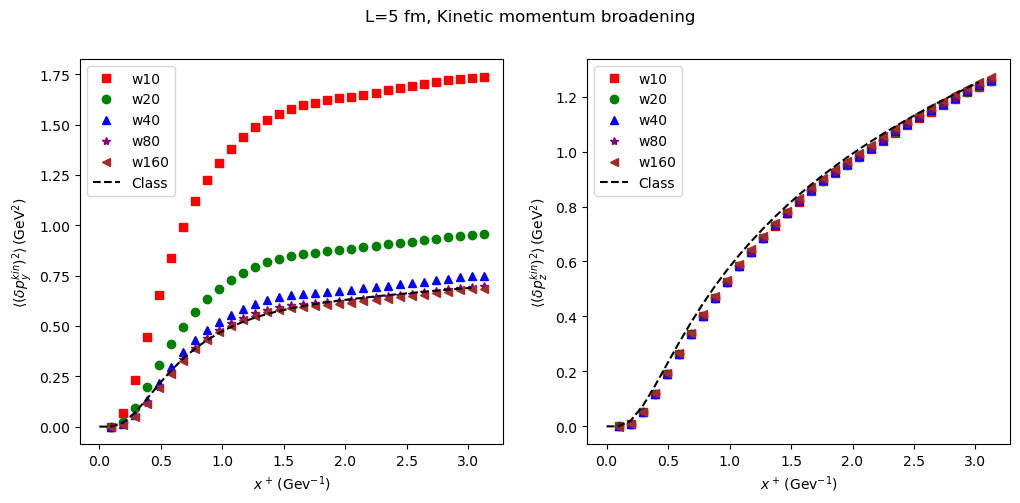

In [18]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w5, '>', label='w5', color='yellow')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w10, 's', label='w10', color='red')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w20, 'o', label='w20', color='green')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w40, '^', label='w40', color='blue')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w80, '*', label='w80', color='purple')
axes[0].plot(xplus+50/(1024)*2, delta_pkin_y2_w160, '<', label='w160', color='brown')
axes[0].plot(xp_class*2/0.197326, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

# axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w5, '>', label='w5', color='yellow')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w10, 's', label='w10', color='red')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w20, 'o', label='w20', color='green')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w40, '^', label='w40', color='blue')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w80, '*', label='w80', color='purple')
axes[1].plot(xplus+50/(1024)*2, delta_pkin_z2_w160, '<', label='w160', color='brown')
axes[1].plot(xp_class*2/0.197326, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=5_plots/Kinetic_momentum_coulomb.pdf', bbox_inches='tight')

In [19]:
# We save the results

np.savetxt('paper_plots/pkin_wz5.txt', [xplus, delta_pkin_y2_w5 , delta_pkin_z2_w5], fmt='%f')
np.savetxt('paper_plots/pkin_wz10.txt', [xplus, delta_pkin_y2_w10 , delta_pkin_z2_w10], fmt='%f')
np.savetxt('paper_plots/pkin_wz20.txt', [xplus, delta_pkin_y2_w20 , delta_pkin_z2_w20], fmt='%f')
np.savetxt('paper_plots/pkin_wz40.txt', [xplus, delta_pkin_y2_w40 , delta_pkin_z2_w40], fmt='%f')
np.savetxt('paper_plots/pkin_wz80.txt', [xplus, delta_pkin_y2_w80 , delta_pkin_z2_w80], fmt='%f')
np.savetxt('paper_plots/pkin_wz160.txt', [xplus, delta_pkin_y2_w160 , delta_pkin_z2_w160], fmt='%f')

## 8. Jet quenching parameter

We load the results

In [1]:
import numpy as np

xplus_q15 = np.loadtxt('classical_results_g2muL=100/m=0_g2mu=1.33.txt')[0]*2/0.197326
xplus_q2= np.loadtxt('classical_results_g2muL=100/m=0_g2mu=2.txt')[0]*2/0.197326
xplus_q25= np.loadtxt('classical_results_g2muL=100/m=0_g2mu=2.5.txt')[0]*2/0.197326

# delta_pkin_y2_q1 = np.loadtxt('Tuomas_extraction/m=0.txt')[1]/3
# delta_pkin_z2_q1 = np.loadtxt('Tuomas_extraction/m=0.txt')[2]/3

delta_pkin_y2_q15 = np.loadtxt('classical_results_g2muL=100/m=0_g2mu=1.33.txt')[1]/3
delta_pkin_z2_q15 = np.loadtxt('classical_results_g2muL=100/m=0_g2mu=1.33.txt')[2]/3

delta_pkin_y2_q2 = np.loadtxt('classical_results_g2muL=100/m=0_g2mu=2.txt')[1]/3
delta_pkin_z2_q2 = np.loadtxt('classical_results_g2muL=100/m=0_g2mu=2.txt')[2]/3

delta_pkin_y2_q25 = np.loadtxt('classical_results_g2muL=100/m=0_g2mu=2.5.txt')[1]/3
delta_pkin_z2_q25 = np.loadtxt('classical_results_g2muL=100/m=0_g2mu=2.5.txt')[2]/3

Compute $\hat{q}$

In [2]:
# delta_pkin2_q1 = delta_pkin_y2_q1 + delta_pkin_z2_q1
delta_pkin2_q15 = delta_pkin_y2_q15 + delta_pkin_z2_q15
delta_pkin2_q2 = delta_pkin_y2_q2 + delta_pkin_z2_q2
delta_pkin2_q25 = delta_pkin_y2_q25 + delta_pkin_z2_q25

In [3]:
# qhat_q1 = np.diff(delta_pkin2_q1/3) / np.diff(xplus)
qhat_q15 = np.diff(delta_pkin_z2_q15) / np.diff(xplus_q15)
qhat_q2 = np.diff(delta_pkin_z2_q2) / np.diff(xplus_q2)
qhat_q25 = np.diff(delta_pkin_z2_q25) / np.diff(xplus_q25)

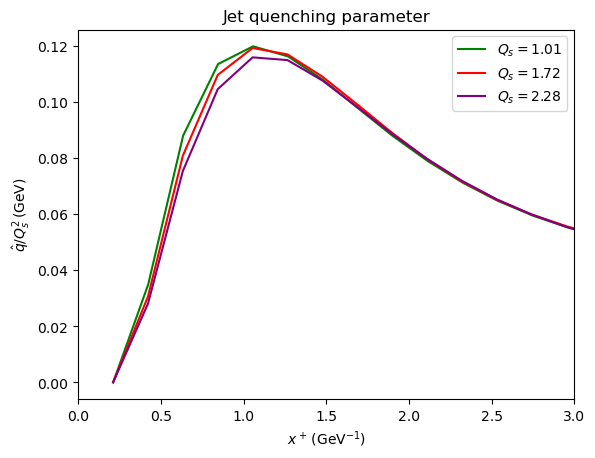

In [8]:
import matplotlib.pyplot as plt

xp_q15 = xplus_q15[1:]
xp_q2 = xplus_q2[1:]
xp_q25 = xplus_q25[1:]

# plt.plot(xp, qhat_q1, label=r'$m/(g^2\mu) = 0$', color='blue')
plt.plot(xp_q15*1.44, qhat_q15/1.44**3, label=r'$Q_s = 1.01$', color='green')
plt.plot(xp_q2*2.16, qhat_q2/2.16**3, label=r'$Q_s = 1.72$', color='red')
plt.plot(xp_q25*2.7, qhat_q25/2.7**3, label=r'$Q_s = 2.28$', color='purple')

# plt.axvline(
#     x=1,
#     color="black",
#     linestyle="--",
#     linewidth=1.2,
#     alpha=0.8,
#     zorder=0,          # draw behind points
#     label=r"$\tau = 0.1 \, \mathrm{fm}$"
# )


plt.xlabel(r'$x^+ \, (\mathrm{GeV}^{-1})$')
plt.ylabel(r'$\hat{q} / Q_s^2 \, (\mathrm{GeV})$')

plt.xlim(0, 3)

plt.legend()
plt.title('Jet quenching parameter')

plt.savefig('L=5_plots/m=0.2_qhat_over_Qs2.pdf', bbox_inches='tight')
plt.show()

Save to file

In [14]:
# We save the results

np.savetxt('paper_plots/qhat_m=0.2_g2mu=1.33.txt', [xp_q15, qhat_q15], fmt='%f')
np.savetxt('paper_plots/qhat_m=0.2_g2mu=2.txt', [xp_q2, qhat_q2], fmt='%f')
np.savetxt('paper_plots/qhat_m=0.2_g2mu=2.5.txt', [xp_q25, qhat_q25], fmt='%f')

### 9. Accumulated momentum

Extract in dimensionless units the momentum broadening accumulated during the Glasma phase

In [8]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import quad

def integrate_qhat(filename, Qs):
    # Load file
    data = np.loadtxt(filename)

    # First row = xplus, second row = qhat
    xplus = data[0]
    qhat = data[1]/2.16**3

    # Interpolation function
    qhat_interp = interp1d(xplus, qhat, kind='linear', fill_value="extrapolate")

    # Upper limit
    xmax = 2.0

    # Integrate
    result, err = quad(qhat_interp, 0.0, xmax)

    return result

accum = integrate_qhat('paper_plots/qhat_m=0_g2mu=2.txt', 1)

print(accum)

0.1311376242361881


/tmp/ipykernel_120823/1441832217.py:20: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, err = quad(qhat_interp, 0.0, xmax)


a, b, c =  [ 0.11930406  0.00507582 -0.07095543]


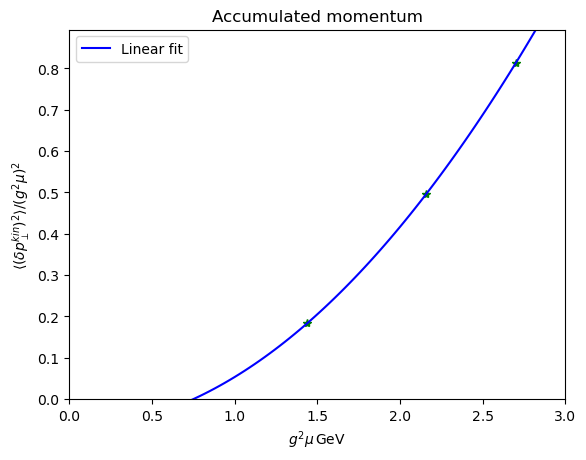

In [11]:
import matplotlib.pyplot as plt

accum_list = [accum_q15, accum_q2, accum_q25]
g2mu_list = [1.44, 2.16, 2.7]
plt.plot(g2mu_list, accum_list, '*', color='green')
# plt.plot(g2mu_list, accum_list/g2mu_list**2, color='green')

# Quadratic fit
coefficients = np.polyfit(g2mu_list, accum_list, 2)
print("a, b, c = ", coefficients)

x_fit = np.linspace(0, 3, 100)
y_fit = coefficients[0] * x_fit**2 + coefficients[1] * x_fit + coefficients[2]
plt.plot(x_fit, y_fit, color='blue', label='Linear fit')

plt.xlabel(r'$g^2\mu \, \mathrm{GeV}$')
plt.ylabel(r'$\langle (\delta p_\perp^{kin})^2 \rangle / (g^2\mu)^2$')

plt.xlim(0, 3)
plt.ylim(0, max(accum_list)*1.1)

plt.legend()
plt.title('Accumulated momentum')

plt.savefig('L=5_plots/accumulated_momentum.pdf', bbox_inches='tight')
plt.show()

Save the results

In [37]:
# We save the results

np.savetxt('paper_plots/accumulated_momentum.txt', [g2mu_list, pac_list/g2mu_list**2], fmt='%f')
np.savetxt('paper_plots/lineal_fit.txt', [x_fit, y_fit], fmt='%f')

## 10. Color rotation

Red the results

In [1]:
# We create a list with the files to read

Nevs = 100

colors_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/paper_results/g2muL=100_g2mu=2.5_color_temp/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_80.000000_wy_80.000000_cQ_1_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_20_Nperp_512_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/evolution_color.dat' %(nev) for nev in range(Nevs)]



In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

colors_df_list = []

for i in range(Nevs):
    
    colors_df = [pd.read_table(colors_list[i], header = None)]
    colors_df_list.append(colors_df)

colors_data = np.array(colors_df_list)

In [3]:
# We average over events
colors_av = np.average(colors_data, axis=(0, 1))

In [4]:
# Extract the color components

xplus = colors_av[:, 0]
color_1 = colors_av[:, 1]
color_2 = colors_av[:, 2]
color_3 = colors_av[:, 3]

Plot the results

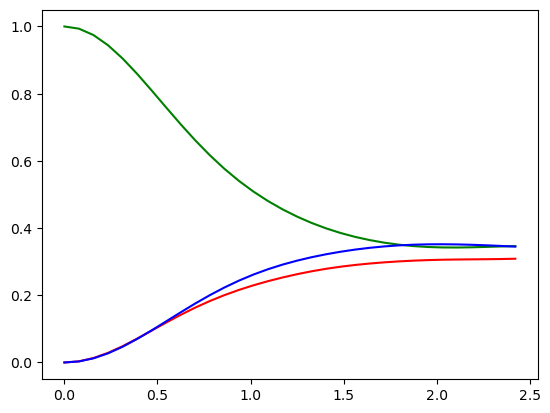

In [5]:
import matplotlib.pyplot as plt

plt.plot(xplus[:-1], color_1[:-1], label='R', color='red')
plt.plot(xplus[:-1], color_2[:-1], label='G', color='green')
plt.plot(xplus[:-1], color_3[:-1], label='B', color='blue')

In [6]:
np.savetxt('paper_plots/colors_temp_g2mu=2.5.txt', [xplus[:-1], color_1[:-1], color_2[:-1], color_3[:-1]], fmt='%f')